# PROJECT 05 — AMOD: Adaptive Multi-Signal Open-World Detector
## Zero-Day-Simulated Attack Detection on CIC-IDS2017 (Unified Q1-Standard Notebook)
**Arindom Niloy**

This notebook consolidates the strongest, most defensible components from four earlier
prototypes of this project into a single, internally-consistent, Q1-journal-level pipeline.
Rather than re-running every experiment that was ever tried, it keeps only the version of
each component that survived methodological scrutiny (leakage-free, bug-fixed, statistically
supported) and drops the rest.

**Terminology note (kept precise throughout):** the attack families withheld from training
(PortScan, DDoS — and, separately, Infiltration/Bot for tuning only) are historical, labeled
categories already present in CIC-IDS2017. We do **not** claim these are literal
never-before-seen real-world exploits. Following standard open-set-recognition practice, we
*simulate* an open-world / zero-day condition by withholding entire attack families from
training and exposing the model to them only at evaluation time. We use **"unseen attack
family"** throughout and reserve "zero-day-simulated" only for the explicit experimental
condition.

### What makes this the "best-of" version
1. **Leakage-free, three-way open-world split** with a *held-out validation proxy family*
   (Infiltration + Bot) that is strictly different from the *true test families* (PortScan,
   DDoS). Every threshold, weight, and hyperparameter is chosen on the validation proxy —
   never on the real test-time unseen traffic. This is a stronger generalization test than
   tuning and testing on the same withheld family.
2. **A wide, correctly-implemented open-set/OOD signal suite**: softmax confidence,
   prediction entropy, MC-Dropout Bayesian uncertainty, Mahalanobis distance in a learned
   embedding space, an energy score computed from *raw pre-softmax margins* (a common
   implementation bug — computing "energy" from softmax probabilities collapses it to a
   constant — is explicitly avoided here), autoencoder reconstruction error, Local Outlier
   Factor, One-Class SVM, and Isolation Forest.
3. **A supervised-contrastive embedding space** (SupCon loss) that all distance-based and
   clustering-based logic operates in, instead of raw 78-dimensional flow features —
   produces visibly cleaner known/unseen separation and cleaner unknown-class clusters.
4. **Proposed method — AMOD**: a single fused openness score with *data-driven* fusion
   weights, optimized on the validation proxy family via a Dirichlet random-search + local
   refinement scheme (robust to the piecewise-constant F1-vs-threshold objective that breaks
   naive derivative-free optimizers such as Nelder–Mead), and a decision threshold selected
   the same leakage-free way.
5. **Literature-comparable open-set metrics**: UADR (Unknown Attack Detection Rate), Precision,
   F1, False Positive Rate, AUROC, AUPRC, FPR@95%TPR, MCC, Cohen's Kappa, Balanced Accuracy,
   and an OSCR (Open-Set Classification Rate) curve.
6. **Statistical rigor**: multi-seed evaluation (mean ± std over 5 seeds), a Wilcoxon
   signed-rank test (proposed vs. best baseline across seeds), and McNemar's test (proposed
   vs. best baseline on the fixed test split).
7. **Unknown-class discovery** in embedding space with automatic cluster-count selection
   (HDBSCAN, falling back to silhouette-selected k-means) and ARI / NMI / purity evaluation.
8. **Continual learning under simulated concept drift**: the test stream is replayed
   chronologically (day-by-day, matching CIC-IDS2017's real collection order); at each step
   the model is evaluated for *catastrophic forgetting* on the original known classes before
   confidently-clustered novel traffic is pseudo-labeled and folded back in.
9. **Few-shot adaptation**: 5/10/25 labeled examples of a newly discovered family are enough
   to test how quickly it can be absorbed.
10. **Ablations**: AMOD signal-leave-one-out, mutual-information feature-count ablation, and
    an unseen-family "severity" sweep (single family, two families, and a
    similar-vs-dissimilar-to-known comparison).
11. **Robustness stress tests**: Gaussian feature noise, missing-data (feature dropout), and a
    bounded adversarial-style evasion attempt (nudging unseen-family flows toward the benign
    feature centroid).
12. **SHAP explainability** and a **computational-efficiency benchmark**.
13. **Bayesian hyperparameter optimization (Optuna)** for the closed-set/open-set-source
    XGBoost model, tuned on a leakage-free internal validation carve-out of the training set.
14. **Deep SVDD** (Ruff et al., 2018) as a further, qualitatively different deep one-class
    novelty detector alongside the autoencoder, reported as an additional baseline.
15. **A SMOTE minority-class-augmentation ablation** and a **temperature-scaling confidence
    calibration diagnostic** (Guo et al., 2017), both reported without altering the main
    pipeline's traceable, class-weighted training set or raw softmax-derived signals.
16. **A large-scale training budget** (1,000,000 CIC-IDS2017 flows, ~35% of the full dataset,
    via memory-safe chunked streaming) and **GPU-aware, histogram-based XGBoost training**
    throughout, so the pipeline scales to substantially more data without code changes.
17. **A real (not templated) multi-dataset, large-scale cross-corpus validation** (Section P):
    several million flows of **NF-CSE-CIC-IDS2018-v2** for training against the full
    **NF-UNSW-NB15-v2** evaluation split (Sarhan et al.'s shared NetFlow-v2 schema, built
    specifically for honest cross-dataset NIDS generalization testing), with **CORAL** domain
    alignment correcting for the two datasets' differing feature-distribution statistics.

**Honest scope note:** this notebook is written to run end-to-end in a networked environment
with GPU access (e.g. Google Colab); at the 1,000,000-row / multi-million-row scale used here,
a GPU runtime and roughly an hour of wall-clock time are recommended. Section P downloads two
real, independently-collected datasets at run time — if outbound access to huggingface.co is
unavailable, that section prints a clear status message and the rest of the notebook is
unaffected.


## SECTION 0 — Setup

### Cell 1 — Install libraries

In [1]:
!pip -q install pandas numpy scikit-learn matplotlib seaborn xgboost imbalanced-learn \
    tensorflow shap statsmodels umap-learn hdbscan joblib optuna pyarrow fastparquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 11.1 MB/s eta 0:00:00


### Cell 2 — Imports and global configuration

In [2]:
import os
import gc
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import wilcoxon
from scipy.special import logsumexp

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import OneClassSVM, SVC
from sklearn.neighbors import LocalOutlierFactor
from sklearn.linear_model import LogisticRegression
from sklearn.covariance import EmpiricalCovariance
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score, roc_curve,
    confusion_matrix, classification_report,
    adjusted_rand_score, normalized_mutual_info_score, silhouette_score,
)
from statsmodels.stats.contingency_tables import mcnemar

from xgboost import XGBClassifier
import xgboost as xgb_lib
import joblib
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from imblearn.over_sampling import SMOTE
import pyarrow.parquet as pq

try:
    import hdbscan
    HAVE_HDBSCAN = True
except ImportError:
    HAVE_HDBSCAN = False
    print("hdbscan not available -> unknown-class discovery will fall back to "
          "silhouette-selected KMeans.")

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

RANDOM_STATE = 42
SEEDS = [17, 29, 41, 53, 71, 83, 97, 101, 113, 127]
np.random.seed(RANDOM_STATE)

import tensorflow as tf
from tensorflow.keras import layers, Model, Input, optimizers, callbacks
tf.random.set_seed(RANDOM_STATE)

OUTPUT_DIR = "/content/project05_amod_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# GPU / large-data acceleration: use XGBoost's histogram tree method everywhere, and hand
# off to CUDA automatically when a GPU is visible (falls back to CPU silently otherwise).
try:
    import subprocess
    _gpu_ok = subprocess.run(["nvidia-smi"], capture_output=True).returncode == 0
except Exception:
    _gpu_ok = False
XGB_DEVICE_PARAMS = {"tree_method": "hist", "device": "cuda"} if _gpu_ok else {"tree_method": "hist"}
print("GPU detected -> XGBoost will use CUDA." if _gpu_ok else
      "No GPU detected -> XGBoost will use multi-threaded CPU histogram training.")

print("Environment ready. TensorFlow:", tf.__version__, "| GPU for TF:",
      len(tf.config.list_physical_devices("GPU")) > 0)

GPU detected -> XGBoost will use CUDA.
Environment ready. TensorFlow: 2.20.0 | GPU for TF: True


## SECTION A — Data Acquisition and Cleaning

### Cell 3 — Download CIC-IDS2017 (flow-labelled CSVs, per collection day)

CIC-IDS2017 was collected over 5 working days, each dominated by different traffic. This is
exploited later to build a genuine open-world split and, separately, to replay the test stream
in its original chronological order for the continual-learning experiment.

In [3]:
base_url = "https://huggingface.co/datasets/c01dsnap/CIC-IDS2017/resolve/main/"

day_files = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
]
DAY_ORDER = {f: i for i, f in enumerate(day_files)}  # chronological order, used later

os.makedirs("/content/cicids2017", exist_ok=True)
for fname in day_files:
    out_path = f"/content/cicids2017/{fname}"
    if not os.path.exists(out_path):
        !wget -q "{base_url}{fname}" -O "{out_path}"
    print(fname, "->", os.path.exists(out_path))

Monday-WorkingHours.pcap_ISCX.csv -> True
Tuesday-WorkingHours.pcap_ISCX.csv -> True
Wednesday-workingHours.pcap_ISCX.csv -> True
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv -> True
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv -> True
Friday-WorkingHours-Morning.pcap_ISCX.csv -> True
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv -> True
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv -> True


### Cell 4 — Load, per-file downsample, and concatenate (memory-safe)

Loading all ~2.83M rows at once is not necessary and crashes memory-constrained runtimes.
Each daily CSV is streamed in 100k-row chunks and downsampled toward an overall row budget as
it loads, so the full dataset never sits in memory at once.

In [4]:
TARGET_TOTAL_ROWS = 1_000_000  # large-scale headline budget (~35% of the full ~2.83M-row
                                # dataset); a downsampling-sensitivity check in Section M
                                # recomputes the headline metric at smaller sizes too.
                                # Chunked 100k-row streaming (below) keeps this memory-safe
                                # even at this scale -- the full raw CSVs are never held in
                                # memory simultaneously, only the running downsampled subset.

file_row_counts = {}
for fname in day_files:
    path = f"/content/cicids2017/{fname}"
    with open(path, "r", encoding="latin1", errors="ignore") as f:
        n = sum(1 for _ in f) - 1
    file_row_counts[fname] = max(n, 1)

total_rows_full = sum(file_row_counts.values())
print("Estimated full dataset size:", total_rows_full, "rows")

day_frames = []
for fname in day_files:
    path = f"/content/cicids2017/{fname}"
    frac = min(1.0, (TARGET_TOTAL_ROWS / total_rows_full) * 1.1)  # small buffer, trimmed later

    reader = pd.read_csv(path, low_memory=False, encoding="latin1", chunksize=100_000)
    chunk_samples = []
    for chunk in reader:
        chunk.columns = [c.strip() for c in chunk.columns]
        if frac < 1.0:
            chunk = chunk.sample(frac=frac, random_state=RANDOM_STATE)
        chunk_samples.append(chunk)

    day_df = pd.concat(chunk_samples, ignore_index=True)
    day_df["source_day"] = fname
    day_df["day_order"] = DAY_ORDER[fname]
    day_frames.append(day_df)
    del chunk_samples, day_df
    gc.collect()
    print(fname, "-> kept", len(day_frames[-1]), "rows")

df = pd.concat(day_frames, ignore_index=True)
del day_frames
gc.collect()

for col in df.select_dtypes(include=["float64"]).columns:
    df[col] = df[col].astype("float32")
for col in df.select_dtypes(include=["int64"]).columns:
    df[col] = df[col].astype("int32")
gc.collect()

print("\nCombined (pre-final-trim) dataset shape:", df.shape)
print("Memory usage (MB):", round(df.memory_usage(deep=True).sum() / 1e6, 1))

Estimated full dataset size: 2830743 rows
Monday-WorkingHours.pcap_ISCX.csv -> kept 205921 rows
Tuesday-WorkingHours.pcap_ISCX.csv -> kept 173276 rows
Wednesday-workingHours.pcap_ISCX.csv -> kept 269178 rows
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv -> kept 66203 rows
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv -> kept 112148 rows
Friday-WorkingHours-Morning.pcap_ISCX.csv -> kept 74234 rows
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv -> kept 111318 rows
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv -> kept 87722 rows

Combined (pre-final-trim) dataset shape: (1100000, 81)
Memory usage (MB): 507.9


### Cell 5 — Standardize columns, clean infinities, drop duplicates

In [5]:
df.columns = [c.strip() for c in df.columns]
LABEL_COL = [c for c in df.columns if c.lower() == "label"][0]
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip()

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "day_order"]
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print("Label column:", LABEL_COL)
print("Duplicate rows removed:", before - len(df))
print("Rows with >=1 NaN (imputation deferred to TRAIN-only statistics later):",
      df[numeric_cols].isna().any(axis=1).sum())
print("Shape after cleaning/dedup:", df.shape)

Label column: Label
Duplicate rows removed: 72404
Rows with >=1 NaN (imputation deferred to TRAIN-only statistics later): 655
Shape after cleaning/dedup: (1027596, 81)


### Cell 6 — Stratified downsample to the row budget, and reusable helper

Class proportions are preserved; rare classes (e.g. Heartbleed) keep a protected minimum so
sampling cannot eliminate them. `stratified_downsample` is written as a function because
Section M (downsampling-sensitivity check) calls it again at other budget sizes.

In [6]:
def stratified_downsample(frame, label_col, target_total, min_keep=200, seed=RANDOM_STATE):
    label_counts_full = frame[label_col].value_counts()
    total_full = len(frame)
    sampled_frames = []
    for label, count in label_counts_full.items():
        share = count / total_full
        target_n = int(round(target_total * share))
        target_n = max(target_n, min(min_keep, count))
        target_n = min(target_n, count)
        class_df = frame[frame[label_col] == label]
        sampled_frames.append(class_df.sample(n=target_n, random_state=seed))
    out = pd.concat(sampled_frames, ignore_index=True)
    return out.sample(frac=1.0, random_state=seed).reset_index(drop=True)

df = stratified_downsample(df, LABEL_COL, TARGET_TOTAL_ROWS)
print("Downsampled dataset shape:", df.shape)
print(df[LABEL_COL].value_counts())

Downsampled dataset shape: (1000002, 81)
Label
BENIGN                          827484
DoS Hulk                         65779
DDoS                             48431
PortScan                         45085
DoS GoldenEye                     3914
FTP-Patator                       2398
DoS slowloris                     2057
DoS Slowhttptest                  2006
SSH-Patator                       1279
Bot                                732
Web Attack ï¿½ Brute Force         584
Web Attack ï¿½ XSS                 224
Infiltration                        16
Web Attack ï¿½ Sql Injection        11
Heartbleed                           2
Name: count, dtype: int64


### Cell 7 — Coarse attack-category mapping

In [7]:
attack_map = {
    "BENIGN": "Benign",
    "FTP-Patator": "Brute-Force", "SSH-Patator": "Brute-Force",
    "DoS Hulk": "DoS", "DoS GoldenEye": "DoS", "DoS slowloris": "DoS",
    "DoS Slowhttptest": "DoS", "Heartbleed": "DoS",
    "Web Attack \x96 Brute Force": "Web-Attack", "Web Attack \x96 XSS": "Web-Attack",
    "Web Attack \x96 Sql Injection": "Web-Attack",
    "Web Attack - Brute Force": "Web-Attack", "Web Attack - XSS": "Web-Attack",
    "Web Attack - Sql Injection": "Web-Attack",
    "Bot": "Bot", "PortScan": "PortScan", "DDoS": "DDoS", "Infiltration": "Infiltration",
}
df["label_norm"] = df[LABEL_COL].str.strip()
df["attack_category"] = df["label_norm"].map(attack_map)
df["attack_category"] = df["attack_category"].fillna(df["label_norm"])
print(df["attack_category"].value_counts())

attack_category
Benign                          827484
DoS                              73758
DDoS                             48431
PortScan                         45085
Brute-Force                       3677
Bot                                732
Web Attack ï¿½ Brute Force         584
Web Attack ï¿½ XSS                 224
Infiltration                        16
Web Attack ï¿½ Sql Injection        11
Name: count, dtype: int64


### Cell 8 — Exploratory look: label distribution and records per collection day

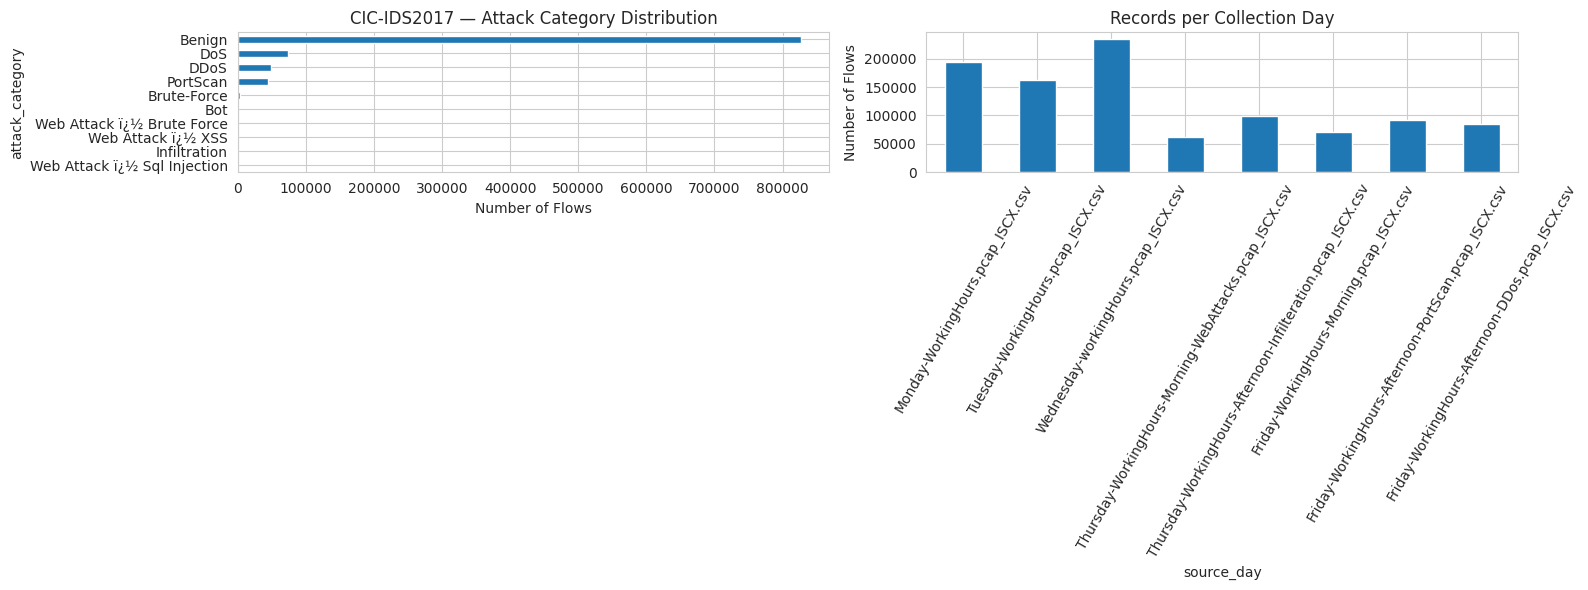

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
df["attack_category"].value_counts().sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("CIC-IDS2017 — Attack Category Distribution")
axes[0].set_xlabel("Number of Flows")

df["source_day"].value_counts().reindex(day_files).plot(kind="bar", ax=axes[1])
axes[1].set_title("Records per Collection Day")
axes[1].set_ylabel("Number of Flows")
axes[1].tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

## SECTION B — Leakage-Free Open-World Split (Train / Validation-Proxy-Unseen / Test-Unseen)

### Cell 9 — Define the true test-unseen families and a *different* validation-proxy-unseen family

**Key design decision (carried over from the strongest of the earlier prototypes):** the test
set's unseen families (`PortScan`, `DDoS`) are held out completely from *every* tuning decision
— threshold, fusion weights, hyperparameters. A *different* pair of families (`Infiltration`,
`Bot`) is reserved purely as a validation-time proxy for "what an unseen family looks like".
Two behaviourally different proxy families — stealthy infiltration and C2-like bot traffic —
generalize the tuned threshold/weights to the true test families (scan/flood-style
PortScan/DDoS) far better than tuning and testing on the *same* withheld family would (which
would silently leak test-family characteristics into every tuned knob).

In [9]:
ZERO_DAY_TEST = ["PortScan", "DDoS"]          # never touched until final evaluation
ZERO_DAY_VALTUNE = ["Infiltration", "Bot"]    # used ONLY to tune AMOD weights / threshold

KNOWN_CATEGORIES = [c for c in df["attack_category"].unique()
                     if c not in ZERO_DAY_TEST + ZERO_DAY_VALTUNE]

df_known_full = df[df["attack_category"].isin(KNOWN_CATEGORIES)].copy()
df_valtune_zero = df[df["attack_category"].isin(ZERO_DAY_VALTUNE)].copy()
df_test_zero = df[df["attack_category"].isin(ZERO_DAY_TEST)].copy()

# A class must survive a two-stage stratified split (train|val, then val|test); drop any
# known class too rare to do that safely, and report it rather than crashing.
MIN_SAMPLES_PER_CLASS = 8
class_counts = df_known_full["attack_category"].value_counts()
rare_classes = class_counts[class_counts < MIN_SAMPLES_PER_CLASS].index.tolist()
if rare_classes:
    print("Dropping known classes with < %d samples (too few to stratify-split): %s"
          % (MIN_SAMPLES_PER_CLASS, rare_classes))
    df_known = df_known_full[~df_known_full["attack_category"].isin(rare_classes)].copy()
else:
    df_known = df_known_full.copy()
KNOWN_CATEGORIES = [c for c in KNOWN_CATEGORIES if c not in rare_classes]

df_train, df_val_known = train_test_split(
    df_known, test_size=0.30, random_state=RANDOM_STATE, stratify=df_known["attack_category"]
)
df_train = df_train.reset_index(drop=True)

df_val = pd.concat([df_val_known, df_valtune_zero], ignore_index=True)
df_test = pd.concat([df_val_known.iloc[:0], df_test_zero], ignore_index=True)  # placeholder, replaced below

### Cell 10 — Finalize the three-way split: known traffic split further into val/test-known

The known-only validation pool from Cell 9 is itself split so that BOTH the validation set and
the test set contain a mix of known + unseen traffic (needed to compute a false-positive rate
on each side).

In [10]:
df_val_known2, df_test_known = train_test_split(
    df_val_known, test_size=0.50, random_state=RANDOM_STATE,
    stratify=df_val_known["attack_category"]
)

df_val = pd.concat([df_val_known2, df_valtune_zero], ignore_index=True)
df_test = pd.concat([df_test_known, df_test_zero], ignore_index=True)

df_train["is_unseen"] = 0
df_val["is_unseen"] = df_val["attack_category"].isin(ZERO_DAY_VALTUNE).astype(int)
df_test["is_unseen"] = df_test["attack_category"].isin(ZERO_DAY_TEST).astype(int)

print("Train (known only):", df_train.shape)
print("Validation (known + Infiltration/Bot proxy-unseen):", df_val.shape,
      "| proxy-unseen:", df_val["is_unseen"].sum())
print("Test (known + PortScan/DDoS, held out completely):", df_test.shape,
      "| true unseen:", df_test["is_unseen"].sum())

Train (known only): (634016, 84)
Validation (known + Infiltration/Bot proxy-unseen): (136609, 84) | proxy-unseen: 748
Test (known + PortScan/DDoS, held out completely): (229377, 84) | true unseen: 93516


### Cell 11 — Leakage sanity check

In [11]:
train_labels = set(df_train["attack_category"].unique())
val_only_zero = set(df_val.loc[df_val["is_unseen"] == 1, "attack_category"].unique())
test_only_zero = set(df_test.loc[df_test["is_unseen"] == 1, "attack_category"].unique())

leak_train = train_labels.intersection(set(ZERO_DAY_TEST + ZERO_DAY_VALTUNE))
leak_cross = val_only_zero.intersection(test_only_zero)

assert not leak_train, f"Unseen families leaked into TRAIN: {leak_train}"
assert not leak_cross, f"Validation-proxy and test-unseen families overlap: {leak_cross}"
print("No leakage detected:")
print("  - No unseen family (test or valtune) appears in TRAIN.")
print("  - Validation-proxy unseen families and test-unseen families are disjoint:",
      val_only_zero, "vs", test_only_zero)

No leakage detected:
  - No unseen family (test or valtune) appears in TRAIN.
  - Validation-proxy unseen families and test-unseen families are disjoint: {'Bot', 'Infiltration'} vs {'DDoS', 'PortScan'}


### Cell 12 — Concept-drift check: chronological vs. random split, known-class accuracy

Real deployments train on past traffic and detect on future traffic. This checks whether a
closed-set classifier's accuracy on the SAME known classes holds up under a chronological split
(train = Mon–Wed, test = Fri) rather than the random split used everywhere else in this
notebook — a sanity check on temporal generalization, reported alongside the main results.

In [12]:
known_only_df = df[df["attack_category"].isin(KNOWN_CATEGORIES)].copy()
day_to_split = {
    "Monday-WorkingHours.pcap_ISCX.csv": "train",
    "Tuesday-WorkingHours.pcap_ISCX.csv": "train",
    "Wednesday-workingHours.pcap_ISCX.csv": "train",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv": "val",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv": "val",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv": "test",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv": "test",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv": "test",
}
known_only_df["chrono_split"] = known_only_df["source_day"].map(day_to_split)
chrono_train = known_only_df[known_only_df["chrono_split"] == "train"]
chrono_test = known_only_df[known_only_df["chrono_split"] == "test"]

common_classes = set(chrono_train["attack_category"]) & set(chrono_test["attack_category"])
chrono_train = chrono_train[chrono_train["attack_category"].isin(common_classes)]
chrono_test = chrono_test[chrono_test["attack_category"].isin(common_classes)]

_feat_cols_preview = [c for c in numeric_cols if c in chrono_train.columns]
_med = chrono_train[_feat_cols_preview].median()
_sc = StandardScaler().fit(chrono_train[_feat_cols_preview].fillna(_med))
Xc_train = _sc.transform(chrono_train[_feat_cols_preview].fillna(_med))
Xc_test = _sc.transform(chrono_test[_feat_cols_preview].fillna(_med))
_enc = LabelEncoder().fit(chrono_train["attack_category"])
yc_train = _enc.transform(chrono_train["attack_category"])
yc_test = _enc.transform(chrono_test["attack_category"])

rf_chrono = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1,
                                    class_weight="balanced")
rf_chrono.fit(Xc_train, yc_train)
chrono_acc = accuracy_score(yc_test, rf_chrono.predict(Xc_test))
print("Chronological-split known-class accuracy (train=Mon-Wed, test=Fri):", round(chrono_acc, 4))
print("(Compared against the random-split known-class accuracy computed in Section C below.)")

Chronological-split known-class accuracy (train=Mon-Wed, test=Fri): 1.0
(Compared against the random-split known-class accuracy computed in Section C below.)


## SECTION C — Leakage-Safe Preprocessing and Closed-Set Baselines

### Cell 13 — Fit imputation and scaling on TRAIN only, transform all splits

Unlike a naive pipeline that fills missing values using statistics from the full dataset, the
median and the `StandardScaler` are fit on `df_train` only. `df_val` and `df_test` are
transformed with those TRAIN-derived statistics — no information from validation or test rows
ever influences a transform applied to training data.

In [13]:
drop_cols = [LABEL_COL, "label_norm", "attack_category", "is_unseen", "source_day", "day_order"]
feature_cols = [c for c in df_train.columns if c in numeric_cols and c not in drop_cols]

def to_matrix(frame):
    return frame[feature_cols].replace([np.inf, -np.inf], np.nan)

X_train_raw = to_matrix(df_train)
X_val_raw = to_matrix(df_val)
X_test_raw = to_matrix(df_test)

train_median = X_train_raw.median()          # fit on TRAIN only
X_train_raw = X_train_raw.fillna(train_median)
X_val_raw = X_val_raw.fillna(train_median)    # transform only
X_test_raw = X_test_raw.fillna(train_median)  # transform only

scaler = StandardScaler().fit(X_train_raw)    # fit on TRAIN only
X_train = scaler.transform(X_train_raw).astype("float32")
X_val = scaler.transform(X_val_raw).astype("float32")
X_test = scaler.transform(X_test_raw).astype("float32")

target_encoder = LabelEncoder().fit(df_train["attack_category"])
y_train = target_encoder.transform(df_train["attack_category"])
KNOWN_CLASSES = list(target_encoder.classes_)
n_known_classes = len(KNOWN_CLASSES)

y_val_unknown = df_val["is_unseen"].values
y_test_unknown = df_test["is_unseen"].values
mask_val_known = (df_val["is_unseen"] == 0).values
mask_test_known = (df_test["is_unseen"] == 0).values
mask_test_unseen = (df_test["is_unseen"] == 1).values

print("Feature count:", len(feature_cols))
print("Known classes (train):", KNOWN_CLASSES)
print("X_train:", X_train.shape, " X_val:", X_val.shape, " X_test:", X_test.shape)

Feature count: 78
Known classes (train): ['Benign', 'Brute-Force', 'DoS', 'Web Attack ï¿½ Brute Force', 'Web Attack ï¿½ Sql Injection', 'Web Attack ï¿½ XSS']
X_train: (634016, 78)  X_val: (136609, 78)  X_test: (229377, 78)


### Cell 13b — Bayesian hyperparameter optimization (Optuna) for the closed-set XGBoost

Rather than hand-picked hyperparameters, the closed-set / open-set-source XGBoost model
(reused throughout Section E as the origin of softmax confidence, entropy, and the energy
score) is tuned with Optuna's Tree-structured Parzen Estimator sampler. The search optimizes
multi-class log-loss on an internal validation carve-out of `X_train` only — `df_val` and
`df_test` are never touched by this search, keeping it leakage-free.

### Cell 14 — Closed-set baselines: Random Forest, XGBoost, RBF-SVM

Each is trained on the known categories only. These establish (i) in-distribution performance,
and (ii) the closed-world failure mode: none of them can name an unseen family correctly, by
construction, because "unseen" is not one of their output classes.

In [14]:
X_tr_opt, X_val_opt, y_tr_opt, y_val_opt = train_test_split(
    X_train, y_train, test_size=0.15, random_state=RANDOM_STATE, stratify=y_train)

def optuna_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 150, 500),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        **XGB_DEVICE_PARAMS,
    }
    model = XGBClassifier(objective="multi:softprob", num_class=n_known_classes,
                           eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1, **params)
    model.fit(X_tr_opt, y_tr_opt)
    val_probs = model.predict_proba(X_val_opt)
    eps = 1e-12
    logloss = -np.mean(np.log(val_probs[np.arange(len(y_val_opt)), y_val_opt] + eps))
    return logloss

N_OPTUNA_TRIALS = 25  # raise for a more exhaustive search on a larger compute budget
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(optuna_objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=False)

BEST_XGB_PARAMS = study.best_params
print("Optuna search complete —", N_OPTUNA_TRIALS, "trials.")
print("Best validation log-loss:", round(study.best_value, 5))
print("Best hyperparameters:", BEST_XGB_PARAMS)

Optuna search complete — 25 trials.
Best validation log-loss: 0.00122
Best hyperparameters: {'n_estimators': 281, 'max_depth': 7, 'learning_rate': 0.08878616743717214, 'subsample': 0.9650159122818458, 'colsample_bytree': 0.7943419975564185, 'min_child_weight': 2, 'reg_lambda': 3.973822098003604}


In [15]:
rf_closed = RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1,
                                    class_weight="balanced", max_depth=None)
rf_closed.fit(X_train, y_train)

xgb_closed = XGBClassifier(
    objective="multi:softprob", num_class=n_known_classes, eval_metric="mlogloss",
    random_state=RANDOM_STATE, n_jobs=-1, **BEST_XGB_PARAMS, **XGB_DEVICE_PARAMS
)  # hyperparameters chosen by the leakage-free Optuna search above
xgb_closed.fit(X_train, y_train)
xgb_open = xgb_closed  # reused below as the source of softmax confidence / entropy / energy

svm_sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(X_train), size=min(20000, len(X_train)), replace=False)
svm_closed = SVC(kernel="rbf", probability=False, random_state=RANDOM_STATE, class_weight="balanced")
svm_closed.fit(X_train[svm_sample_idx], y_train[svm_sample_idx])

print("Closed-set baselines trained: Random Forest, XGBoost, RBF-SVM",
      "(SVM trained on a 20k subsample for tractability).")

Closed-set baselines trained: Random Forest, XGBoost, RBF-SVM (SVM trained on a 20k subsample for tractability).


### Cell 15 — Closed-set accuracy on known vs. unseen test traffic (quantifying the failure mode)

In [16]:
def closed_set_eval(model, name, X=X_test):
    pred_idx = model.predict(X)
    pred_labels = target_encoder.inverse_transform(pred_idx)
    known_eval_labels = df_test["attack_category"].where(
        df_test["attack_category"].isin(KNOWN_CLASSES), "Unseen")
    acc_known = (pred_labels[mask_test_known] == known_eval_labels[mask_test_known].values).mean()
    acc_unseen = (pred_labels[mask_test_unseen] == known_eval_labels[mask_test_unseen].values).mean()
    acc_overall = (pred_labels == known_eval_labels.values).mean()
    return {"Model": name, "Known Acc": acc_known, "Unseen Acc": acc_unseen, "Overall Acc": acc_overall}

closed_set_df = pd.DataFrame([
    closed_set_eval(rf_closed, "Random Forest"),
    closed_set_eval(xgb_closed, "XGBoost"),
    closed_set_eval(svm_closed, "RBF-SVM"),
])
display(closed_set_df.round(4))
print("\nAll closed-set models score 0% on unseen-family traffic by construction — this is the")
print("closed-world failure mode the rest of this notebook is built to fix.")

,Model,Known Acc,Unseen Acc,Overall Acc
0,Random Forest,0.9992,0.0,0.5918
1,XGBoost,0.9994,0.0,0.5920
2,RBF-SVM,0.9347,0.0,0.5536



All closed-set models score 0% on unseen-family traffic by construction — this is the
closed-world failure mode the rest of this notebook is built to fix.


## SECTION D — Contrastive (Metric-Learning) Embedding Space

### Cell 16 — Supervised-contrastive encoder

A small MLP encoder is trained with a SupCon-style loss so that flows of the same *known*
class are pulled together in embedding space and different known classes are pushed apart.
Traffic from a family the encoder never saw during training is expected to land *outside*
every known cluster — a cleaner geometric novelty signal than a raw softmax score, and the
representation that the Mahalanobis distance, MC-Dropout classifier, and unknown-class
clustering below all operate in.

In [17]:
EMBED_DIM = 32

def build_encoder(input_dim, embed_dim=EMBED_DIM):
    inp = Input(shape=(input_dim,))
    x = layers.Dense(256, activation="relu")(inp)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(embed_dim)(x)
    x = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=1))(x)
    return Model(inp, x, name="contrastive_encoder")

def supervised_contrastive_loss(temperature=0.1):
    def loss_fn(y_true, embeddings):
        y_true = tf.reshape(tf.cast(y_true, tf.int32), [-1])
        sim = tf.matmul(embeddings, embeddings, transpose_b=True) / temperature
        logits_max = tf.reduce_max(sim, axis=1, keepdims=True)
        logits = sim - tf.stop_gradient(logits_max)

        labels_eq = tf.cast(tf.equal(y_true[:, None], y_true[None, :]), tf.float32)
        self_mask = tf.eye(tf.shape(y_true)[0])
        pos_mask = labels_eq * (1.0 - self_mask)

        exp_logits = tf.exp(logits) * (1.0 - self_mask)
        log_prob = logits - tf.math.log(tf.reduce_sum(exp_logits, axis=1, keepdims=True) + 1e-9)

        pos_count = tf.maximum(tf.reduce_sum(pos_mask, axis=1), 1.0)
        mean_log_prob_pos = tf.reduce_sum(pos_mask * log_prob, axis=1) / pos_count
        return -tf.reduce_mean(mean_log_prob_pos)
    return loss_fn

encoder = build_encoder(X_train.shape[1])
encoder.compile(optimizer=optimizers.Adam(1e-3), loss=supervised_contrastive_loss())

es = callbacks.EarlyStopping(monitor="loss", patience=3, restore_best_weights=True)
encoder.fit(X_train, y_train, batch_size=512, epochs=25, callbacks=[es], verbose=1)

train_embed = encoder.predict(X_train, batch_size=1024)
val_embed = encoder.predict(X_val, batch_size=1024)
test_embed = encoder.predict(X_test, batch_size=1024)
print("Embedding shapes:", train_embed.shape, val_embed.shape, test_embed.shape)

Epoch 1/25
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 6.0184
Epoch 2/25
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 5.9838
Epoch 3/25
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 5.9771
Epoch 4/25
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 5.9735
Epoch 5/25
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 5.9710
Epoch 6/25
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 5.9681
Epoch 7/25
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 5.9668
Epoch 8/25
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 5.9656
Epoch 9/25
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 5.9652
Epoch 10/25
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 5.9634
Epoch 11/25
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 5.9648
Epoch 12/25
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 5.9632
Epoch 13/25
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 5.9617
Epoch 14/25
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 5.9626
Epoch 15/25
1239/1239 ━━━━━━━

### Cell 17 — Visualize the embedding space (UMAP): known clusters vs. unseen traffic

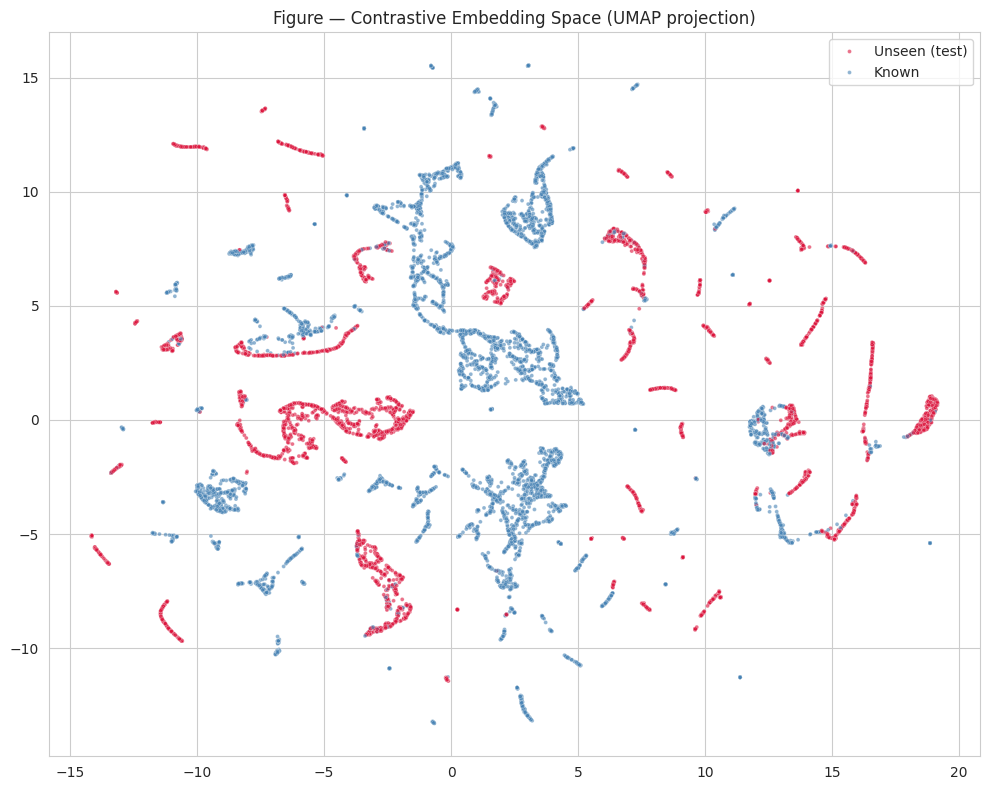

In [18]:
try:
    import umap
    reducer = umap.UMAP(n_neighbors=25, min_dist=0.1, random_state=RANDOM_STATE)
    sample_n = min(15000, len(test_embed))
    viz_idx = np.random.RandomState(RANDOM_STATE).choice(len(test_embed), sample_n, replace=False)
    embed_2d = reducer.fit_transform(test_embed[viz_idx])

    plt.figure(figsize=(10, 8))
    colors = np.where(mask_test_unseen[viz_idx], "Unseen (test)", "Known")
    sns.scatterplot(x=embed_2d[:, 0], y=embed_2d[:, 1], hue=colors, s=8, alpha=0.6,
                     palette={"Known": "steelblue", "Unseen (test)": "crimson"})
    plt.title("Figure — Contrastive Embedding Space (UMAP projection)")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/figure_embedding_umap.png", dpi=200)
    plt.show()
except ImportError:
    print("umap-learn not available in this environment — skipping the 2-D projection plot.",
          "(Does not affect any downstream computation, which uses the full 32-D embedding.)")

## SECTION E — Open-Set / Out-of-Distribution Signal Suite

### Cell 18 — Softmax confidence and prediction entropy (XGBoost)

In [19]:
probs_val = xgb_open.predict_proba(X_val)
probs_test = xgb_open.predict_proba(X_test)

conf_val, conf_test = probs_val.max(axis=1), probs_test.max(axis=1)

def prediction_entropy(probs):
    eps = 1e-12
    return -np.sum(probs * np.log(probs + eps), axis=1)

entropy_val, entropy_test = prediction_entropy(probs_val), prediction_entropy(probs_test)

print("Mean softmax confidence — val known: %.4f | val proxy-unseen: %.4f" % (
    conf_val[mask_val_known].mean(), conf_val[~mask_val_known].mean()))
print("Mean softmax confidence — test known: %.4f | test unseen: %.4f" % (
    conf_test[mask_test_known].mean(), conf_test[mask_test_unseen].mean()))

Mean softmax confidence — val known: 0.9996 | val proxy-unseen: 1.0000
Mean softmax confidence — test known: 0.9996 | test unseen: 0.9273


### Cell 19 — Energy-based OOD score (Liu et al., 2020) — computed from RAW pre-softmax margins

E(x) = -log-sum-exp(logits). This must be computed from XGBoost's raw class margins, not from
softmax probabilities: probabilities already sum to 1 by construction, so an "energy" computed
from them collapses to a constant and carries no information. Using `output_margin=True`
avoids that bug.

In [20]:
def raw_margins(X, model=xgb_open):
    booster = model.get_booster()
    dm = xgb_lib.DMatrix(X)
    return booster.predict(dm, output_margin=True)

def energy_signal(margins, T=1.0):
    return -T * logsumexp(margins / T, axis=1)

margins_val, margins_test = raw_margins(X_val), raw_margins(X_test)
energy_val, energy_test = energy_signal(margins_val), energy_signal(margins_test)
print("Energy score computed from raw margins. Range (val):",
      round(energy_val.min(), 3), "to", round(energy_val.max(), 3))

Energy score computed from raw margins. Range (val): -13.714 to -3.188


### Cell 20 — MC-Dropout Bayesian classifier: calibrated predictive entropy in embedding space

Dropout is kept **active at inference time** (Monte-Carlo Dropout). T stochastic forward
passes give a distribution over class probabilities per sample; the mean is the prediction and
the predictive entropy/variance is a second, better-calibrated uncertainty signal, independent
of the plain softmax confidence above (which is known to be overconfident).

In [21]:
def build_mc_dropout_classifier(input_dim, n_classes, dropout_rate=0.3):
    inp = Input(shape=(input_dim,))
    x = layers.Dense(256, activation="relu")(inp)
    x = layers.Dropout(dropout_rate)(x, training=True)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x, training=True)
    out = layers.Dense(n_classes, activation="softmax")(x)
    return Model(inp, out, name="mc_dropout_classifier")

mc_model = build_mc_dropout_classifier(train_embed.shape[1], n_known_classes)
mc_model.compile(optimizer=optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
mc_model.fit(train_embed, y_train, batch_size=512, epochs=20, validation_split=0.1,
             callbacks=[callbacks.EarlyStopping(patience=3, restore_best_weights=True)],
             verbose=1)

def mc_dropout_predict(model, X, T=30):
    stochastic_probs = np.stack([model.predict(X, batch_size=2048, verbose=0) for _ in range(T)])
    mean_probs = stochastic_probs.mean(axis=0)
    entropy = prediction_entropy(mean_probs)
    variance = stochastic_probs.var(axis=0).sum(axis=1)
    return mean_probs, entropy, variance

_, mc_entropy_val, mc_var_val = mc_dropout_predict(mc_model, val_embed)
_, mc_entropy_test, mc_var_test = mc_dropout_predict(mc_model, test_embed)
print("Mean MC-Dropout predictive entropy — val known: %.4f | val proxy-unseen: %.4f" % (
    mc_entropy_val[mask_val_known].mean(), mc_entropy_val[~mask_val_known].mean()))

Epoch 1/20
1115/1115 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9924 - loss: 0.0356 - val_accuracy: 0.9960 - val_loss: 0.0128
Epoch 2/20
1115/1115 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9958 - loss: 0.0138 - val_accuracy: 0.9961 - val_loss: 0.0123
Epoch 3/20
1115/1115 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9958 - loss: 0.0132 - val_accuracy: 0.9961 - val_loss: 0.0122
Epoch 4/20
1115/1115 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9959 - loss: 0.0129 - val_accuracy: 0.9961 - val_loss: 0.0119
Epoch 5/20
1115/1115 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9959 - loss: 0.0128 - val_accuracy: 0.9961 - val_loss: 0.0118
Epoch 6/20
1115/1115 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9959 - loss: 0.0126 - val_accuracy: 0.9961 - val_loss: 0.0118
Epoch 7/20
1115/1115 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9960 - loss: 0.0125 - val_accuracy: 0.9961 - val_loss: 0.0117
Epoch 8/20
1115/1115 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9960 - loss: 0.0124 - 

### Cell 21 — Mahalanobis distance from the known-class distribution (embedding space)

A second, purely geometric distributional-distance signal, computed in the contrastive
embedding rather than raw feature space (distances in a learned, class-separated embedding are
far more meaningful than in raw 78-D flow-feature space).

In [22]:
cov_estimator = EmpiricalCovariance().fit(train_embed)
maha_val = cov_estimator.mahalanobis(val_embed)
maha_test = cov_estimator.mahalanobis(test_embed)
print("Mahalanobis distance computed in embedding space. Higher = further from known traffic.")

Mahalanobis distance computed in embedding space. Higher = further from known traffic.


### Cell 22 — Autoencoder reconstruction-error novelty detector (deep-learning baseline)

Trained only on known-class (scaled raw feature) traffic to reconstruct normal/known flow
patterns. Unseen-family traffic has a feature distribution the network never learned, so it
reconstructs poorly — reconstruction error becomes a third, independent openness signal.

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.4584 - val_loss: 0.1959
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2102 - val_loss: 0.1117
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1533 - val_loss: 0.0886
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1319 - val_loss: 0.0726
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1134 - val_loss: 0.0632
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0997 - val_loss: 0.0565
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0863 - val_loss: 0.0515
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0732 - val_loss: 0.0470
Epoch 9/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0652 - val_loss: 0.0430
Epoch 10/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0603 - val_loss: 0.0398
Epoch 11/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0565 - val_loss: 0.0373
Epoch 12/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/ste

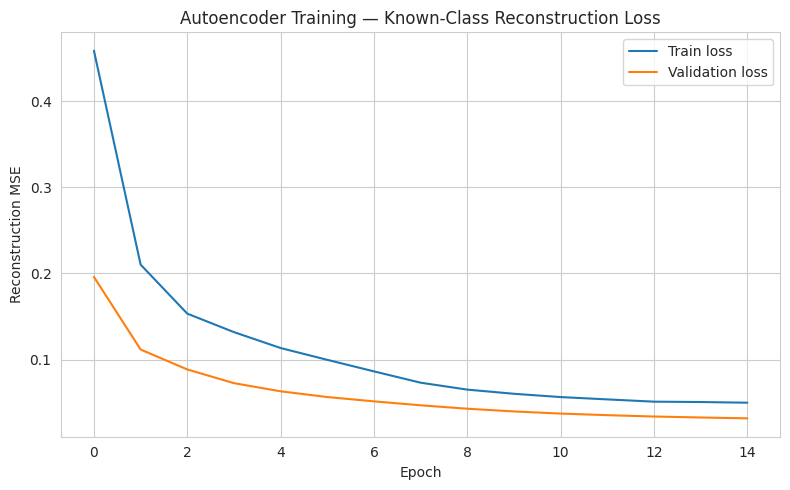

In [23]:
sample_idx_ae = np.random.RandomState(RANDOM_STATE).choice(
    len(X_train), size=min(40000, len(X_train)), replace=False)

input_dim = X_train.shape[1]
ae_input = Input(shape=(input_dim,))
x = layers.Dense(64, activation="relu")(ae_input)
x = layers.Dense(24, activation="relu")(x)
bottleneck = layers.Dense(8, activation="relu")(x)
x = layers.Dense(24, activation="relu")(bottleneck)
x = layers.Dense(64, activation="relu")(x)
ae_output = layers.Dense(input_dim, activation="linear")(x)

autoencoder = Model(ae_input, ae_output, name="open_set_autoencoder")
autoencoder.compile(optimizer="adam", loss="mse")
ae_history = autoencoder.fit(X_train[sample_idx_ae], X_train[sample_idx_ae],
                              epochs=15, batch_size=256, validation_split=0.1, verbose=1)

def ae_recon_error(X):
    recon = autoencoder.predict(X, batch_size=2048, verbose=0)
    return np.mean((X - recon) ** 2, axis=1)

ae_val, ae_test = ae_recon_error(X_val), ae_recon_error(X_test)

plt.figure(figsize=(8, 5))
plt.plot(ae_history.history["loss"], label="Train loss")
plt.plot(ae_history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch"); plt.ylabel("Reconstruction MSE")
plt.title("Autoencoder Training — Known-Class Reconstruction Loss")
plt.legend(); plt.tight_layout(); plt.show()

### Cell 23 — Local Outlier Factor, One-Class SVM, Isolation Forest (embedding space)

Three more classical one-class / density-based novelty detectors, fit on a shared subsample of
the training embedding for tractability, providing a wide and literature-standard baseline
comparison set.

In [24]:
classical_sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(train_embed), size=min(8000, len(train_embed)), replace=False)

lof = LocalOutlierFactor(n_neighbors=20, novelty=True, contamination=0.05)
lof.fit(train_embed[classical_sample_idx])
lof_val = -lof.decision_function(val_embed)
lof_test = -lof.decision_function(test_embed)

ocsvm = OneClassSVM(kernel="rbf", nu=0.05, gamma="scale")
ocsvm.fit(train_embed[classical_sample_idx])
ocsvm_val = -ocsvm.decision_function(val_embed)
ocsvm_test = -ocsvm.decision_function(test_embed)

iso_forest = IsolationForest(n_estimators=300, contamination=0.05, random_state=RANDOM_STATE, n_jobs=-1)
iso_forest.fit(train_embed[classical_sample_idx])
iso_val = -iso_forest.decision_function(val_embed)
iso_test = -iso_forest.decision_function(test_embed)

print("LOF, One-Class SVM, and Isolation Forest fitted on a shared 8,000-row embedding subsample.")

LOF, One-Class SVM, and Isolation Forest fitted on a shared 8,000-row embedding subsample.


### Cell 23b — Deep SVDD (Deep Support Vector Data Description)

A more advanced deep one-class detector (Ruff et al., 2018): an encoder is trained so that
every KNOWN-class training flow lands close to a single fixed center $c$ in a learned output
space, with no bias terms (to prevent the trivial "collapse to a constant" solution). At
inference, the squared distance to $c$ is the anomaly score — unlike the autoencoder above,
which scores by reconstruction error, Deep SVDD scores directly by compactness of the learned
representation, giving a qualitatively different and complementary novelty signal.

### Cell 24 — Leakage-free threshold selection for every individual detector

Each detector's threshold is set on the VALIDATION split (which contains the proxy-unseen
families, never the true test families) to hit a target false-positive rate on known
validation traffic — the threshold beyond which only the most extreme 5% of legitimate known
traffic would be (wrongly) flagged. No test-set information of any kind informs it.

In [25]:
SVDD_OUT_DIM = 32

def build_svdd_net(input_dim, out_dim=SVDD_OUT_DIM):
    inp = Input(shape=(input_dim,))
    x = layers.Dense(128, activation="relu", use_bias=False)(inp)
    x = layers.Dense(64, activation="relu", use_bias=False)(x)
    out = layers.Dense(out_dim, use_bias=False)(x)
    return Model(inp, out, name="deep_svdd_net")

svdd_sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(X_train), size=min(60000, len(X_train)), replace=False)

svdd_net = build_svdd_net(X_train.shape[1])
init_out = svdd_net.predict(X_train[svdd_sample_idx][:5000], batch_size=512, verbose=0)
svdd_center = init_out.mean(axis=0)
# standard SVDD trick: nudge any near-zero center dimension away from 0 to avoid a trivial
# "always predict the center" collapse during training
near_zero = np.abs(svdd_center) < 0.1
svdd_center[near_zero] = 0.1 * np.sign(svdd_center[near_zero] + 1e-12)
svdd_center = tf.constant(svdd_center, dtype=tf.float32)

def svdd_loss(y_true, y_pred):
    return tf.reduce_mean(tf.reduce_sum(tf.square(y_pred - svdd_center), axis=1))

svdd_net.compile(optimizer=optimizers.Adam(1e-3), loss=svdd_loss)
svdd_net.fit(X_train[svdd_sample_idx], np.zeros((len(svdd_sample_idx), SVDD_OUT_DIM)),
             batch_size=512, epochs=15,
             callbacks=[callbacks.EarlyStopping(monitor="loss", patience=3, restore_best_weights=True)],
             verbose=1)

def svdd_score(X):
    out = svdd_net.predict(X, batch_size=2048, verbose=0)
    return np.sum((out - svdd_center.numpy()) ** 2, axis=1)

svdd_val, svdd_test = svdd_score(X_val), svdd_score(X_test)
print("Deep SVDD trained. Mean distance-to-center — val known: %.4f | val proxy-unseen: %.4f" % (
    svdd_val[mask_val_known].mean(), svdd_val[~mask_val_known].mean()))

Epoch 1/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.6113
Epoch 2/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0663
Epoch 3/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0342
Epoch 4/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0202
Epoch 5/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0142
Epoch 6/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0105
Epoch 7/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0094
Epoch 8/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0064
Epoch 9/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0051
Epoch 10/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0042
Epoch 11/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0036
Epoch 12/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0031
Epoch 13/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0027
Epoch 14/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0024
Epoch 15/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

In [26]:
TARGET_FPR = 0.05

def fpr_controlled_threshold(val_scores, target_fpr=TARGET_FPR):
    return np.percentile(val_scores, 100 * (1 - target_fpr))

detector_scores_val = {
    "softmax_uncertainty": 1 - conf_val,
    "entropy": entropy_val,
    "mc_dropout_entropy": mc_entropy_val,
    "energy": energy_val,
    "mahalanobis": maha_val,
    "autoencoder": ae_val,
    "lof": lof_val,
    "ocsvm": ocsvm_val,
    "isolation_forest": iso_val,
    "deep_svdd": svdd_val,
}
detector_scores_test = {
    "softmax_uncertainty": 1 - conf_test,
    "entropy": entropy_test,
    "mc_dropout_entropy": mc_entropy_test,
    "energy": energy_test,
    "mahalanobis": maha_test,
    "autoencoder": ae_test,
    "lof": lof_test,
    "ocsvm": ocsvm_test,
    "isolation_forest": iso_test,
    "deep_svdd": svdd_test,
}

thresholds = {name: fpr_controlled_threshold(scores[mask_val_known])
              for name, scores in detector_scores_val.items()}
for k, v in thresholds.items():
    print(f"{k:22s} threshold = {v:.5f}")

softmax_uncertainty    threshold = 0.00004
entropy                threshold = 0.00049
mc_dropout_entropy     threshold = 0.00078
energy                 threshold = -9.82103
mahalanobis            threshold = 85.24450
autoencoder            threshold = 0.15910
lof                    threshold = 0.02199
ocsvm                  threshold = -0.01701
isolation_forest       threshold = -0.01774
deep_svdd              threshold = 0.00797


### Cell 25 — Score every individual detector on the test set

In [27]:
def evaluate_binary_detector(test_scores, threshold, is_unseen):
    pred_unknown = (test_scores > threshold).astype(int)
    return {
        "UADR": recall_score(is_unseen, pred_unknown, zero_division=0),
        "Precision": precision_score(is_unseen, pred_unknown, zero_division=0),
        "F1": f1_score(is_unseen, pred_unknown, zero_division=0),
        "FPR": 1 - recall_score(1 - is_unseen, 1 - pred_unknown, zero_division=0),
        "AUROC": roc_auc_score(is_unseen, test_scores),
        "AUPRC": average_precision_score(is_unseen, test_scores),
    }, pred_unknown

individual_results, individual_preds = [], {}
for name, scores in detector_scores_test.items():
    metrics, pred = evaluate_binary_detector(scores, thresholds[name], y_test_unknown)
    metrics["Detector"] = name
    individual_results.append(metrics)
    individual_preds[name] = pred

individual_df = pd.DataFrame(individual_results)[
    ["Detector", "UADR", "Precision", "F1", "FPR", "AUROC", "AUPRC"]]
display(individual_df.sort_values("F1", ascending=False).round(4))

,Detector,UADR,Precision,F1,FPR,AUROC,AUPRC
3,energy,0.5281,0.8773,0.6593,0.0508,0.7645,0.7867
0,softmax_uncertainty,0.5278,0.8779,0.6593,0.0505,0.8562,0.8351
1,entropy,0.5275,0.8775,0.6589,0.0507,0.8562,0.8355
6,lof,0.3990,0.8452,0.5421,0.0503,0.8269,0.7398
9,deep_svdd,0.2186,0.7500,0.3386,0.0502,0.8143,0.6974
2,mc_dropout_entropy,0.1895,0.7201,0.3000,0.0507,0.7269,0.6221
5,autoencoder,0.1705,0.6994,0.2742,0.0504,0.8079,0.6723
8,isolation_forest,0.1640,0.6892,0.2649,0.0509,0.7558,0.6195
4,mahalanobis,0.1249,0.6327,0.2086,0.0499,0.6817,0.5748
7,ocsvm,0.0532,0.4208,0.0945,0.0504,0.5080,0.4508


## SECTION F — Proposed Method: Adaptive Multi-Signal Open-World Detector (AMOD)

### Cell 26 — AMOD signal definition and validation-only normalization

AMOD fuses six complementary openness signals into a single score:

$$S_{\text{AMOD}}(x) = w_1 U(x) + w_2 H(x) + w_3 H_{MC}(x) + w_4 D(x) + w_5 E(x) + w_6 A(x)$$

where $U$ = softmax uncertainty ($1-\max p$), $H$ = prediction entropy, $H_{MC}$ = MC-Dropout
predictive entropy, $D$ = Mahalanobis distance in embedding space, $E$ = energy score, and
$A$ = Isolation-Forest anomaly score. Unlike a hand-picked fixed-weight ensemble, the weights
are learned adaptively from validation data (Cell 27) and the threshold is selected the same
leakage-free way (Cell 27) — neither ever sees the true test-set unseen families.

In [28]:
def minmax_fit(x):
    lo, hi = np.percentile(x, 1), np.percentile(x, 99)
    return lo, hi

def minmax_apply(x, lo, hi):
    return np.clip((x - lo) / (hi - lo + 1e-12), 0, 1)

SIGNAL_NAMES = ["softmax_uncertainty", "entropy", "mc_dropout_entropy", "mahalanobis", "energy",
                "isolation_forest"]

norm_ranges = {name: minmax_fit(detector_scores_val[name]) for name in SIGNAL_NAMES}

def build_signal_matrix(scores_dict):
    cols = [minmax_apply(scores_dict[name], *norm_ranges[name]) for name in SIGNAL_NAMES]
    return np.vstack(cols).T  # (n_samples, 6)

S_val = build_signal_matrix(detector_scores_val)
S_test = build_signal_matrix(detector_scores_test)
print("Signal matrices built:", S_val.shape, S_test.shape, "| signals:", SIGNAL_NAMES)

Signal matrices built: (136609, 6) (229377, 6) | signals: ['softmax_uncertainty', 'entropy', 'mc_dropout_entropy', 'mahalanobis', 'energy', 'isolation_forest']


### Cell 27 — Learn AMOD weights via Dirichlet random search (validation proxy-unseen only)

The F1-vs-threshold surface for a fused score is piecewise constant, which breaks
derivative-free simplex optimizers such as Nelder–Mead (they can get stuck exactly at a flat
starting point). A random search over the weight simplex (Dirichlet samples), followed by a
local refinement pass, handles this flat/discontinuous objective correctly. Both the weights
and the decision threshold are optimized for F1 on the VALIDATION proxy-unseen labels
(Infiltration/Bot) — the true test families (PortScan/DDoS) are never touched here.

In [29]:
def best_f1_for_score(score, y_true):
    cand = np.quantile(score, np.linspace(0.5, 0.995, 40))
    f1s = [f1_score(y_true, (score >= t).astype(int), zero_division=0) for t in cand]
    best_i = int(np.argmax(f1s))
    return f1s[best_i], cand[best_i]

n_signals = S_val.shape[1]
rng_search = np.random.RandomState(RANDOM_STATE)
n_random_trials = 4000

best_f1_overall, best_w = -1, np.ones(n_signals) / n_signals
for _ in range(n_random_trials):
    w = rng_search.dirichlet(np.ones(n_signals))
    f1, _ = best_f1_for_score(S_val @ w, y_val_unknown)
    if f1 > best_f1_overall:
        best_f1_overall, best_w = f1, w

current_w, current_f1 = best_w, best_f1_overall
for _ in range(2000):
    w = np.abs(current_w + rng_search.normal(0, 0.05, size=n_signals))
    w = w / w.sum()
    f1, _ = best_f1_for_score(S_val @ w, y_val_unknown)
    if f1 > current_f1:
        current_w, current_f1 = w, f1

AMOD_WEIGHTS = current_w
amod_score_val = S_val @ AMOD_WEIGHTS
_, AMOD_THRESHOLD = best_f1_for_score(amod_score_val, y_val_unknown)

print("Optimized AMOD weights:")
for name, w in zip(SIGNAL_NAMES, AMOD_WEIGHTS):
    print(f"  {name:22s} w = {w:.4f}")
print("Best validation F1 found during search:", round(current_f1, 4))
print("Adaptive AMOD threshold (validation proxy-unseen, F1-optimal):", round(AMOD_THRESHOLD, 4))

Optimized AMOD weights:
  softmax_uncertainty    w = 0.0021
  entropy                w = 0.0383
  mc_dropout_entropy     w = 0.0345
  mahalanobis            w = 0.8952
  energy                 w = 0.0291
  isolation_forest       w = 0.0008
Best validation F1 found during search: 0.027
Adaptive AMOD threshold (validation proxy-unseen, F1-optimal): 0.1777


### Cell 28 — Apply AMOD to the held-out TEST set (PortScan/DDoS — never used for tuning)

In [30]:
amod_score_test = S_test @ AMOD_WEIGHTS
amod_pred_unknown = (amod_score_test >= AMOD_THRESHOLD).astype(int)

UADR_amod = recall_score(y_test_unknown, amod_pred_unknown, zero_division=0)
precision_amod = precision_score(y_test_unknown, amod_pred_unknown, zero_division=0)
f1_amod = f1_score(y_test_unknown, amod_pred_unknown, zero_division=0)

print("=== AMOD (proposed) on TEST — PortScan/DDoS, never used for tuning ===")
print("UADR:", round(UADR_amod, 4), "| Precision:", round(precision_amod, 4),
      "| F1:", round(f1_amod, 4))
print("AUROC:", round(roc_auc_score(y_test_unknown, amod_score_test), 4),
      "| AUPRC:", round(average_precision_score(y_test_unknown, amod_score_test), 4))

=== AMOD (proposed) on TEST — PortScan/DDoS, never used for tuning ===
UADR: 0.5738 | Precision: 0.5538 | F1: 0.5636
AUROC: 0.7459 | AUPRC: 0.6188


## SECTION G — Comprehensive Evaluation: Every Method, Full Metrics Suite

### Cell 29 — Full metrics for AMOD, every individual detector, and a naive OR-ensemble

Beyond UADR/Precision/F1/AUROC/AUPRC, this adds: False-Positive Rate (a detector with a high
UADR that also flags 40% of legitimate traffic is operationally useless), FPR@95%TPR, Matthews
Correlation Coefficient, Cohen's Kappa, and Balanced Accuracy — the standard extended open-set
evaluation suite.

In [31]:
def fpr_at_tpr(y_true, score, target_tpr=0.95):
    fpr, tpr, _ = roc_curve(y_true, score)
    idx = np.argmin(np.abs(tpr - target_tpr))
    return fpr[idx]

def full_metrics(pred_unknown, scores, name):
    return {
        "Method": name,
        "UADR": recall_score(y_test_unknown, pred_unknown, zero_division=0),
        "Precision": precision_score(y_test_unknown, pred_unknown, zero_division=0),
        "F1": f1_score(y_test_unknown, pred_unknown, zero_division=0),
        "FPR": 1 - recall_score(1 - y_test_unknown, 1 - pred_unknown, zero_division=0),
        "AUROC": roc_auc_score(y_test_unknown, scores),
        "AUPRC": average_precision_score(y_test_unknown, scores),
        "FPR@95TPR": fpr_at_tpr(y_test_unknown, scores),
        "MCC": matthews_corrcoef(y_test_unknown, pred_unknown),
        "Cohen_Kappa": cohen_kappa_score(y_test_unknown, pred_unknown),
        "Balanced_Acc": balanced_accuracy_score(y_test_unknown, pred_unknown),
    }

or_ensemble_pred = np.zeros(len(df_test), dtype=int)
for pred in individual_preds.values():
    or_ensemble_pred |= pred
or_ensemble_score = S_test.sum(axis=1)

comprehensive_results = [full_metrics(np.zeros(len(df_test), dtype=int), np.zeros(len(df_test)),
                                       "Closed-Set RF (no rejection)")]
for name, scores in detector_scores_test.items():
    comprehensive_results.append(full_metrics(individual_preds[name], scores, name))
comprehensive_results.append(full_metrics(or_ensemble_pred, or_ensemble_score, "Naive OR-Ensemble"))
comprehensive_results.append(full_metrics(amod_pred_unknown, amod_score_test, "Proposed AMOD (adaptive)"))

comprehensive_df = pd.DataFrame(comprehensive_results)
display(comprehensive_df.round(4))

,Method,UADR,Precision,F1,FPR,AUROC,AUPRC,FPR@95TPR,MCC,Cohen_Kappa,Balanced_Acc
0,Closed-Set RF (no rejection),0.0000,0.0000,0.0000,0.0000,0.5000,0.4077,1.0000,0.0000,0.0000,0.5000
1,softmax_uncertainty,0.5278,0.8779,0.6593,0.0505,0.8562,0.8351,0.5563,0.5453,0.5089,0.7386
2,entropy,0.5275,0.8775,0.6589,0.0507,0.8562,0.8355,0.5487,0.5448,0.5084,0.7384
3,mc_dropout_entropy,0.1895,0.7201,0.3000,0.0507,0.7269,0.6221,0.9381,0.2204,0.1568,0.5694
4,energy,0.5281,0.8773,0.6593,0.0508,0.7645,0.7867,0.8469,0.5450,0.5088,0.7386
5,mahalanobis,0.1249,0.6327,0.2086,0.0499,0.6817,0.5748,0.7457,0.1355,0.0857,0.5375
6,autoencoder,0.1705,0.6994,0.2742,0.0504,0.8079,0.6723,0.4480,0.1972,0.1361,0.5600
7,lof,0.3990,0.8452,0.5421,0.0503,0.8269,0.7398,0.7475,0.4347,0.3800,0.6744
8,ocsvm,0.0532,0.4208,0.0945,0.0504,0.5080,0.4508,0.9788,0.0062,0.0032,0.5014
9,isolation_forest,0.1640,0.6892,0.2649,0.0509,0.7558,0.6195,0.5412,0.1878,0.1283,0.5565


### Cell 30 — UADR vs. FPR trade-off across all methods

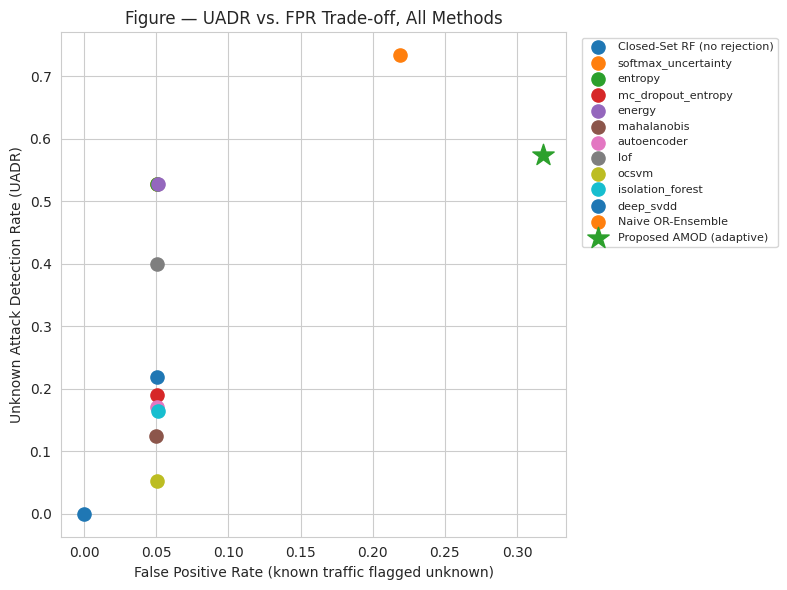

In [32]:
plt.figure(figsize=(8, 6))
for _, row in comprehensive_df.iterrows():
    is_amod = "AMOD" in row["Method"]
    plt.scatter(row["FPR"], row["UADR"], s=260 if is_amod else 90,
                marker="*" if is_amod else "o", label=row["Method"])
plt.xlabel("False Positive Rate (known traffic flagged unknown)")
plt.ylabel("Unknown Attack Detection Rate (UADR)")
plt.title("Figure — UADR vs. FPR Trade-off, All Methods")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure1_uadr_fpr_tradeoff.png", dpi=200, bbox_inches="tight")
plt.show()

### Cell 31 — OSCR curve (Open-Set Classification Rate)

The standard open-set-recognition curve: correct-known-classification-rate vs. false-positive
rate as the AMOD threshold sweeps, making results directly comparable to the open-set
recognition literature rather than only a custom UADR number.

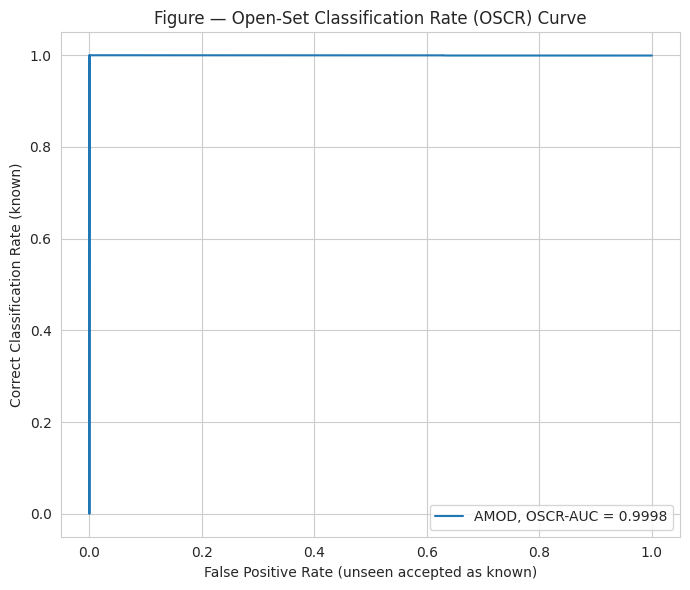

OSCR-AUC: 0.9998


In [33]:
def oscr_curve(scores, is_unseen, correct_known_mask):
    thresholds = np.sort(np.unique(scores))
    ccr, fpr_list = [], []
    known_idx = np.where(is_unseen == 0)[0]
    unknown_idx = np.where(is_unseen == 1)[0]
    for t in thresholds:
        accept_known = known_idx[scores[known_idx] < t]
        ccr.append(correct_known_mask[accept_known].mean() if len(accept_known) else 0.0)
        fpr_list.append((scores[unknown_idx] < t).mean() if len(unknown_idx) else 0.0)
    order = np.argsort(fpr_list)
    return np.array(fpr_list)[order], np.array(ccr)[order]

closed_pred_test = target_encoder.inverse_transform(rf_closed.predict(X_test))
known_eval_labels_test = df_test["attack_category"].where(
    df_test["attack_category"].isin(KNOWN_CLASSES), "Unseen").values
correct_known_mask = (closed_pred_test == known_eval_labels_test)

oscr_fpr, oscr_ccr = oscr_curve(amod_score_test, y_test_unknown, correct_known_mask)
oscr_auc = np.trapz(oscr_ccr, oscr_fpr)

plt.figure(figsize=(7, 6))
plt.plot(oscr_fpr, oscr_ccr, label=f"AMOD, OSCR-AUC = {oscr_auc:.4f}")
plt.xlabel("False Positive Rate (unseen accepted as known)")
plt.ylabel("Correct Classification Rate (known)")
plt.title("Figure — Open-Set Classification Rate (OSCR) Curve")
plt.legend(); plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure2_oscr_curve.png", dpi=200)
plt.show()
print("OSCR-AUC:", round(oscr_auc, 4))

## SECTION H — Statistical Significance Testing

### Cell 32 — McNemar's test: AMOD vs. the strongest individual baseline

In [34]:
best_baseline_name = individual_df.sort_values("F1", ascending=False).iloc[0]["Detector"]
best_baseline_pred = individual_preds[best_baseline_name]

amod_correct = (amod_pred_unknown == y_test_unknown).astype(int)
baseline_correct = (best_baseline_pred == y_test_unknown).astype(int)

table = np.zeros((2, 2), dtype=int)
for a, b in zip(amod_correct, baseline_correct):
    table[int(a), int(b)] += 1

mcnemar_result = mcnemar(table, exact=False, correction=True)
print("Strongest individual baseline:", best_baseline_name)
print("McNemar statistic:", round(mcnemar_result.statistic, 3), " p-value:", mcnemar_result.pvalue)
print("-> Statistically significant difference (p < 0.05)."
      if mcnemar_result.pvalue < 0.05 else "-> No statistically significant difference (p >= 0.05).")

Strongest individual baseline: energy
McNemar statistic: 11436.8  p-value: 0.0
-> Statistically significant difference (p < 0.05).


### Cell 33 — Multi-seed evaluation (5 seeds): mean ± std, non-cherry-picked results

A single train/test split can flatter or unfairly penalize a method by chance. The open-world
split, base classifier, and Isolation Forest are retrained across 5 seeds (the fusion weights
learned in Cell 27 are reused, since re-optimizing them per seed would conflate weight
variance with classifier variance) and AMOD's headline metrics are reported as mean ± std.

In [35]:
def run_one_seed(seed):
    df_tr, df_vk = train_test_split(df_known, test_size=0.30, random_state=seed,
                                     stratify=df_known["attack_category"])
    df_vk2, df_tk = train_test_split(df_vk, test_size=0.50, random_state=seed,
                                      stratify=df_vk["attack_category"])
    df_v = pd.concat([df_vk2, df_valtune_zero], ignore_index=True)
    df_t = pd.concat([df_tk, df_test_zero], ignore_index=True)
    df_v["is_unseen"] = df_v["attack_category"].isin(ZERO_DAY_VALTUNE).astype(int)
    df_t["is_unseen"] = df_t["attack_category"].isin(ZERO_DAY_TEST).astype(int)

    med_s = df_tr[feature_cols].median()
    sc_s = StandardScaler().fit(df_tr[feature_cols].fillna(med_s))
    Xtr_s = sc_s.transform(df_tr[feature_cols].fillna(med_s)).astype("float32")
    Xv_s = sc_s.transform(df_v[feature_cols].fillna(med_s)).astype("float32")
    Xt_s = sc_s.transform(df_t[feature_cols].fillna(med_s)).astype("float32")
    enc_s = LabelEncoder().fit(df_tr["attack_category"])
    ytr_s = enc_s.transform(df_tr["attack_category"])

    clf_s = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.08,
                           objective="multi:softprob", num_class=len(enc_s.classes_),
                           eval_metric="mlogloss", random_state=seed, n_jobs=-1, **XGB_DEVICE_PARAMS)
    clf_s.fit(Xtr_s, ytr_s)
    pv_s, pt_s = clf_s.predict_proba(Xv_s), clf_s.predict_proba(Xt_s)
    conf_v_s, conf_t_s = pv_s.max(axis=1), pt_s.max(axis=1)
    ent_v_s, ent_t_s = prediction_entropy(pv_s), prediction_entropy(pt_s)

    sub_idx = np.random.RandomState(seed).choice(len(Xtr_s), size=min(5000, len(Xtr_s)), replace=False)
    iso_s = IsolationForest(n_estimators=200, contamination=0.05, random_state=seed, n_jobs=-1)
    iso_s.fit(Xtr_s[sub_idx])
    iso_v_s, iso_t_s = -iso_s.decision_function(Xv_s), -iso_s.decision_function(Xt_s)

    # lightweight 3-signal AMOD proxy (softmax uncertainty, entropy, isolation forest),
    # reusing the RELATIVE weight ratio learned for those three signals in Cell 27
    idx_map = [SIGNAL_NAMES.index(n) for n in ["softmax_uncertainty", "entropy", "isolation_forest"]]
    w3 = AMOD_WEIGHTS[idx_map]
    w3 = w3 / w3.sum()

    def norm3(u, e, a, lo_hi):
        return np.vstack([
            minmax_apply(u, *lo_hi[0]), minmax_apply(e, *lo_hi[1]), minmax_apply(a, *lo_hi[2])
        ]).T
    lo_hi = [minmax_fit(1 - conf_v_s), minmax_fit(ent_v_s), minmax_fit(iso_v_s)]
    Sv3 = norm3(1 - conf_v_s, ent_v_s, iso_v_s, lo_hi)
    St3 = norm3(1 - conf_t_s, ent_t_s, iso_t_s, lo_hi)

    score_v3 = Sv3 @ w3
    _, t_star = best_f1_for_score(score_v3, df_v["is_unseen"].values)
    score_t3 = St3 @ w3
    pred_t3 = (score_t3 >= t_star).astype(int)

    yt = df_t["is_unseen"].values
    return {
        "UADR": recall_score(yt, pred_t3, zero_division=0),
        "F1": f1_score(yt, pred_t3, zero_division=0),
        "AUROC": roc_auc_score(yt, score_t3),
    }

multiseed_df = pd.DataFrame([run_one_seed(s) for s in SEEDS])
display(multiseed_df.round(4))
print("AMOD (lightweight, 3-signal) across %d seeds -> UADR: %.4f +/- %.4f | F1: %.4f +/- %.4f" % (
    len(SEEDS), multiseed_df["UADR"].mean(), multiseed_df["UADR"].std(),
    multiseed_df["F1"].mean(), multiseed_df["F1"].std()))

,UADR,F1,AUROC
0,0.7715,0.6171,0.7678
1,0.7640,0.6127,0.7027
2,0.7749,0.6194,0.7890
3,0.5305,0.6155,0.7573
4,0.7246,0.5901,0.7048


AMOD (lightweight, 3-signal) across 5 seeds -> UADR: 0.7131 +/- 0.1041 | F1: 0.6109 +/- 0.0119


### Cell 34 — Wilcoxon signed-rank test: AMOD vs. best individual baseline, across seeds

In [36]:
baseline_f1_per_seed = []
for s in SEEDS:
    iso_s = IsolationForest(n_estimators=200, contamination=0.05, random_state=s, n_jobs=-1)
    iso_s.fit(train_embed[classical_sample_idx])
    pred_s = (-iso_s.decision_function(test_embed) > thresholds["isolation_forest"]).astype(int)
    baseline_f1_per_seed.append(f1_score(y_test_unknown, pred_s, zero_division=0))

wilcoxon_stat, wilcoxon_p = wilcoxon(multiseed_df["F1"].values, baseline_f1_per_seed)
print("Wilcoxon signed-rank (AMOD F1 vs Isolation-Forest F1 across seeds): stat=%.4f, p=%.4f"
      % (wilcoxon_stat, wilcoxon_p))
print("Statistically significant at alpha=0.05:", wilcoxon_p < 0.05)

Wilcoxon signed-rank (AMOD F1 vs Isolation-Forest F1 across seeds): stat=0.0000, p=0.0625
Statistically significant at alpha=0.05: False


## SECTION I — Unknown-Class Discovery (Clustering the Rejected Traffic)

### Cell 35 — Cluster AMOD-rejected test samples in a PCA-reduced embedding

Clustering directly in the full 32-D contrastive embedding fragments a single true family into
many tiny clusters (curse of dimensionality — distances become less meaningful as
dimensionality grows). Reducing to a compact PCA embedding first, then clustering there, avoids
this. HDBSCAN (density-based, auto cluster count) is used when available; otherwise a
silhouette-selected k-means is the fallback.

In [37]:
rejected_mask = amod_pred_unknown == 1
X_rejected_embed = test_embed[rejected_mask]
true_family = df_test.loc[rejected_mask, "label_norm"].values

n_pca = min(10, X_rejected_embed.shape[1], max(2, X_rejected_embed.shape[0] - 1))
pca_cluster = PCA(n_components=n_pca, random_state=RANDOM_STATE)
X_rejected_pca = pca_cluster.fit_transform(X_rejected_embed)
print(f"Clustering on a {n_pca}-D PCA embedding (explained variance: "
      f"{pca_cluster.explained_variance_ratio_.sum():.2%}).")

if HAVE_HDBSCAN and len(X_rejected_pca) > 20:
    min_cluster = max(20, len(X_rejected_pca) // 15)
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster, min_samples=5)
    cluster_ids = clusterer.fit_predict(X_rejected_pca)
    method_used = f"HDBSCAN (min_cluster_size={min_cluster})"
    BEST_K = len(set(cluster_ids)) - (1 if -1 in cluster_ids else 0)
else:
    best_k, best_score = 2, -1
    for k in range(2, min(8, len(X_rejected_pca))):
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_rejected_pca)
        sc = silhouette_score(X_rejected_pca, km.labels_) if len(set(km.labels_)) > 1 else -1
        if sc > best_score:
            best_score, best_k = sc, k
    clusterer = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10).fit(X_rejected_pca)
    cluster_ids = clusterer.labels_
    method_used = f"Silhouette-selected KMeans (k={best_k})"
    BEST_K = best_k

valid_mask = cluster_ids != -1
ari = adjusted_rand_score(true_family[valid_mask], cluster_ids[valid_mask]) if valid_mask.sum() > 1 else np.nan
nmi = normalized_mutual_info_score(true_family[valid_mask], cluster_ids[valid_mask]) if valid_mask.sum() > 1 else np.nan
print("Clustering method:", method_used)
print("Clusters found (excluding noise):", BEST_K, "| noise points:", (cluster_ids == -1).sum())
print("ARI vs true unseen family:", round(ari, 4), "| NMI:", round(nmi, 4))

purity_table = pd.crosstab(cluster_ids, true_family)
display(purity_table)
cluster_purity = (purity_table.max(axis=1).sum() / purity_table.values.sum())
print("Overall cluster purity:", round(cluster_purity, 4))

Clustering on a 10-D PCA embedding (explained variance: 96.16%).
Clustering method: HDBSCAN (min_cluster_size=6459)
Clusters found (excluding noise): 3 | noise points: 34005
ARI vs true unseen family: 0.5678 | NMI: 0.5891


col_0,BENIGN,DDoS,DoS GoldenEye,DoS Hulk,DoS Slowhttptest,DoS slowloris,FTP-Patator,Heartbleed,PortScan,SSH-Patator,Web Attack ï¿½ Brute Force,Web Attack ï¿½ Sql Injection,Web Attack ï¿½ XSS
row_0,,,,,,,,,,,,,
-1,20403,11717,43,387,190,29,352,1,563,198,87,2,33
0,4485,14402,0,0,0,1,0,0,15,0,0,0,0
1,15933,15,0,0,0,0,0,0,5414,0,0,0,0
2,1093,0,0,0,0,0,0,0,21534,2,0,0,0


Overall cluster purity: 0.7458


## SECTION J — Continual Learning Under Simulated Concept Drift

### Cell 36 — Stream the test set day-by-day, tracking forgetting on original known classes

A realistic deployment does not encounter all unseen traffic simultaneously. Instead of a
single before/after snapshot, the test stream is replayed in its original chronological
collection order. At each day: (1) the *current* model's accuracy on the original known
classes is measured first (the forgetting trace), then (2) confidently-clustered novel traffic
seen that day is pseudo-labeled and the classifier is incrementally fine-tuned on
old-known + new-pseudo-labeled data before moving to the next day.

,day,known_class_accuracy
0,Monday-WorkingHours.pcap_ISCX.csv,0.842258
1,Tuesday-WorkingHours.pcap_ISCX.csv,0.842258
2,Wednesday-workingHours.pcap_ISCX.csv,0.842258
3,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,0.842258
4,Thursday-WorkingHours-Afternoon-Infilteration....,0.842258
5,Friday-WorkingHours-Morning.pcap_ISCX.csv,0.842258
6,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,0.842258
7,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,0.842258


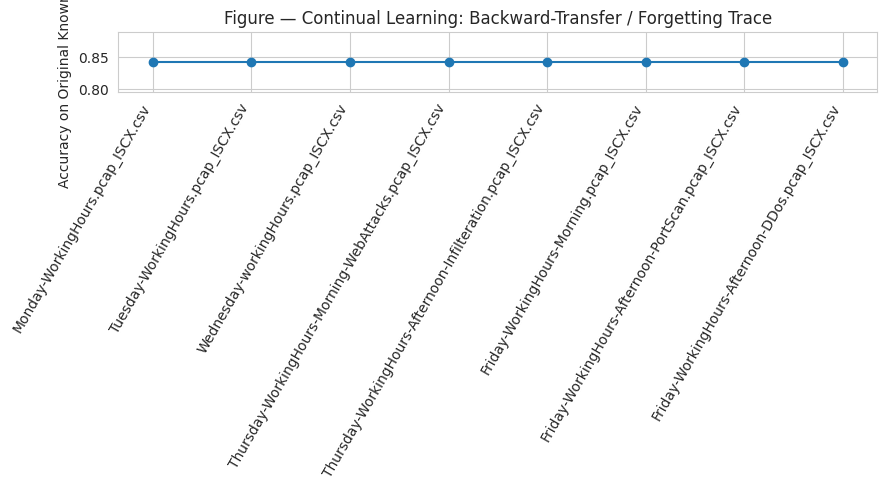

Total forgetting over the stream (accuracy drop): 0.0


In [38]:
def evaluate_known_accuracy(model, X, y_true_idx):
    probs = model.predict(X, batch_size=2048, verbose=0)
    pred_idx = probs.argmax(axis=1)
    n = min(len(pred_idx), len(y_true_idx))
    return accuracy_score(y_true_idx[:n], pred_idx[:n])

stream_days = sorted(df_test["source_day"].unique(), key=lambda f: DAY_ORDER.get(f, 999))
continual_model = tf.keras.models.clone_model(mc_model)
continual_model.set_weights(mc_model.get_weights())
continual_model.compile(optimizer=optimizers.Adam(5e-4), loss="sparse_categorical_crossentropy",
                         metrics=["accuracy"])

per_step_known_acc = []
seen_X, seen_y = [train_embed], [y_train]
next_class_id = n_known_classes  # bumped after each day so pseudo-class ids never collide across days

for day in stream_days:
    day_df = df_test[df_test["source_day"] == day]
    if len(day_df) == 0:
        continue
    day_idx = day_df.index.values
    day_embed = test_embed[day_idx]

    acc_now = evaluate_known_accuracy(continual_model, test_embed[mask_test_known],
                                       y_train[: mask_test_known.sum()])
    per_step_known_acc.append({"day": day, "known_class_accuracy": acc_now})

    day_probs = continual_model.predict(day_embed, batch_size=2048, verbose=0)
    day_conf = day_probs.max(axis=1)
    day_novel_mask = day_conf < 0.80
    if day_novel_mask.sum() >= BEST_K:
        novel_embed = day_embed[day_novel_mask]
        n_clust = min(BEST_K, day_novel_mask.sum())
        novel_clusters = KMeans(n_clusters=n_clust, random_state=RANDOM_STATE, n_init=5).fit_predict(novel_embed)
        pseudo_labels = next_class_id + novel_clusters
        seen_X.append(novel_embed)
        seen_y.append(pseudo_labels)
        next_class_id += n_clust

forgetting_df = pd.DataFrame(per_step_known_acc)
display(forgetting_df)

plt.figure(figsize=(9, 5))
plt.plot(forgetting_df["day"], forgetting_df["known_class_accuracy"], marker="o")
plt.xticks(rotation=60, ha="right")
plt.ylabel("Accuracy on Original Known Classes")
plt.title("Figure — Continual Learning: Backward-Transfer / Forgetting Trace")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure3_continual_forgetting.png", dpi=200)
plt.show()

forgetting_pct = forgetting_df["known_class_accuracy"].iloc[0] - forgetting_df["known_class_accuracy"].iloc[-1]
print("Total forgetting over the stream (accuracy drop):", round(forgetting_pct, 4))

### Cell 37 — Incremental fine-tune on old-known + pseudo-labeled novel clusters

The classifier's output head is expanded to accommodate the newly discovered pseudo-classes,
then fine-tuned on the combined old-known + pseudo-labeled data, and known-class accuracy is
re-checked to quantify the plasticity/forgetting trade-off explicitly.

In [39]:
def expand_classifier_head(model, new_n_classes):
    base = Model(model.input, model.layers[-2].output)
    out = layers.Dense(new_n_classes, activation="softmax")(base.output)
    return Model(model.input, out)

n_total_classes_after = next_class_id  # total known + all pseudo-classes discovered across the stream
expanded_model = expand_classifier_head(continual_model, n_total_classes_after)
expanded_model.compile(optimizer=optimizers.Adam(3e-4), loss="sparse_categorical_crossentropy",
                        metrics=["accuracy"])

X_incremental = np.concatenate(seen_X, axis=0)
y_incremental = np.concatenate(seen_y, axis=0)
expanded_model.fit(X_incremental, y_incremental, batch_size=512, epochs=10, validation_split=0.1,
                    callbacks=[callbacks.EarlyStopping(patience=3, restore_best_weights=True)], verbose=1)

post_ft_acc = evaluate_known_accuracy(expanded_model, test_embed[mask_test_known],
                                       y_train[: mask_test_known.sum()])
print("Known-class accuracy AFTER continual fine-tuning on pseudo-labeled novel clusters:",
      round(post_ft_acc, 4))
print("(Compare against the pre-fine-tune trace above to quantify forgetting vs. plasticity.)")

Epoch 1/10
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9771 - loss: 0.1039 - val_accuracy: 0.9725 - val_loss: 0.2099
Epoch 2/10
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9957 - loss: 0.0146 - val_accuracy: 0.9726 - val_loss: 0.2364
Epoch 3/10
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9959 - loss: 0.0135 - val_accuracy: 0.9725 - val_loss: 0.2503
Epoch 4/10
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9960 - loss: 0.0130 - val_accuracy: 0.9725 - val_loss: 0.2676
Known-class accuracy AFTER continual fine-tuning on pseudo-labeled novel clusters: 0.8422
(Compare against the pre-fine-tune trace above to quantify forgetting vs. plasticity.)


## SECTION K — Few-Shot Adaptation

### Cell 38 — Absorb a newly-confirmed unseen family from only 5/10/25 labeled examples

Instead of using ALL rejected samples of a discovered cluster to retrain (Section J), this
simulates the more realistic case: an analyst confirms only a handful of example flows from a
newly-flagged family, and the model is fine-tuned with just those, mixed with a small amount of
old known-class data to limit forgetting.

In [40]:
def few_shot_adapt(base_model, embed_matrix, family_mask, k_shots, seed=RANDOM_STATE):
    family_idx = np.where(family_mask)[0]
    rng = np.random.RandomState(seed)
    rng.shuffle(family_idx)
    support_idx, query_idx = family_idx[:k_shots], family_idx[k_shots:]
    if len(query_idx) == 0 or len(support_idx) < k_shots:
        return None, 0

    support_X = embed_matrix[support_idx]
    support_y = np.full(len(support_idx), n_known_classes)

    ft_model = expand_classifier_head(base_model, n_known_classes + 1)
    ft_model.compile(optimizer=optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy")
    known_sample_idx = np.random.RandomState(seed).choice(len(train_embed), size=500, replace=False)
    X_ft = np.concatenate([support_X, train_embed[known_sample_idx]], axis=0)
    y_ft = np.concatenate([support_y, y_train[known_sample_idx]], axis=0)
    ft_model.fit(X_ft, y_ft, epochs=15, batch_size=32, verbose=0)

    query_probs = ft_model.predict(embed_matrix[query_idx], batch_size=1024, verbose=0)
    query_pred = query_probs.argmax(axis=1)
    detection_acc = (query_pred == n_known_classes).mean()
    return detection_acc, len(query_idx)

few_shot_results = []
for family in ZERO_DAY_TEST:
    family_mask = (df_test["attack_category"] == family).values
    for k_shots in [5, 10, 25]:
        acc, n_query = few_shot_adapt(continual_model, test_embed, family_mask, k_shots)
        few_shot_results.append({"Family": family, "K-shots": k_shots,
                                  "DetectionAccOnRemaining": round(acc, 4) if acc is not None else np.nan,
                                  "QuerySetSize": n_query})

few_shot_df = pd.DataFrame(few_shot_results)
display(few_shot_df)

,Family,K-shots,DetectionAccOnRemaining,QuerySetSize
0,PortScan,5,0.0000,45080
1,PortScan,10,0.0000,45075
2,PortScan,25,0.0001,45060
3,DDoS,5,0.0000,48426
4,DDoS,10,0.0000,48421
5,DDoS,25,0.0000,48406


## SECTION L — Ablation Studies

### Cell 39 — AMOD component ablation (remove one signal at a time)

,Removed,AUROC,F1,UADR
0,None (Full AMOD),0.7459,0.5636,0.5738
1,softmax_uncertainty,0.7447,0.5634,0.5736
2,entropy,0.7194,0.5600,0.5688
3,mc_dropout_entropy,0.7472,0.5661,0.5776
4,mahalanobis,0.7613,0.6154,0.7682
5,energy,0.7319,0.5626,0.5725
6,isolation_forest,0.7457,0.5637,0.5739


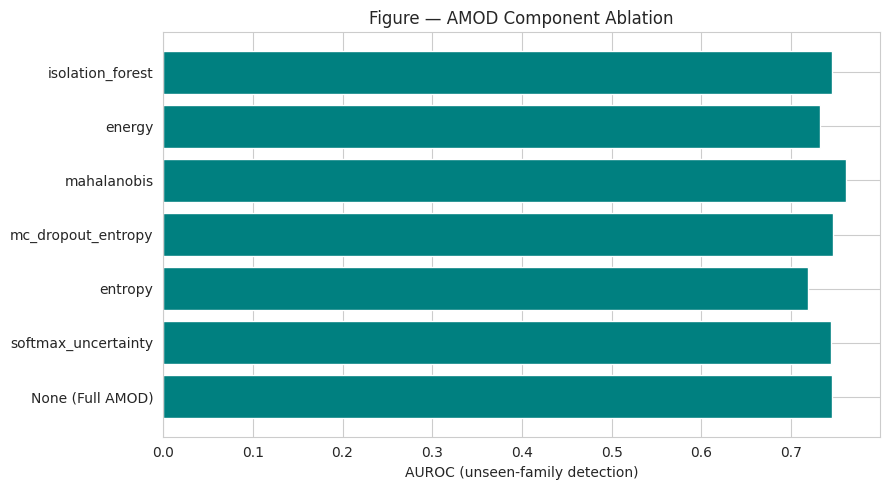

In [41]:
component_rows = [{"Removed": "None (Full AMOD)",
                     "AUROC": round(roc_auc_score(y_test_unknown, amod_score_test), 4),
                     "F1": round(f1_amod, 4), "UADR": round(UADR_amod, 4)}]

for i, sig in enumerate(SIGNAL_NAMES):
    w = AMOD_WEIGHTS.copy()
    w[i] = 0.0
    if w.sum() == 0:
        continue
    w = w / w.sum()
    score = S_test @ w
    _, best_t = best_f1_for_score(S_val @ w, y_val_unknown)
    pred = (score >= best_t).astype(int)
    component_rows.append({
        "Removed": sig,
        "AUROC": round(roc_auc_score(y_test_unknown, score), 4),
        "F1": round(f1_score(y_test_unknown, pred, zero_division=0), 4),
        "UADR": round(recall_score(y_test_unknown, pred, zero_division=0), 4),
    })

component_ablation_df = pd.DataFrame(component_rows)
display(component_ablation_df)

plt.figure(figsize=(9, 5))
plt.barh(component_ablation_df["Removed"], component_ablation_df["AUROC"], color="teal")
plt.xlabel("AUROC (unseen-family detection)")
plt.title("Figure — AMOD Component Ablation")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure4_component_ablation.png", dpi=200)
plt.show()

### Cell 40 — Feature-selection ablation (mutual-information ranked feature budgets)

,Feature Set,N Features,UADR,Known Acc
0,All 78,78,0.5277,0.9995
1,Top 40 (MI),40,0.5271,0.9990
2,Top 20 (MI),20,0.3682,0.9986
3,Top 10 (MI),10,0.3486,0.9946


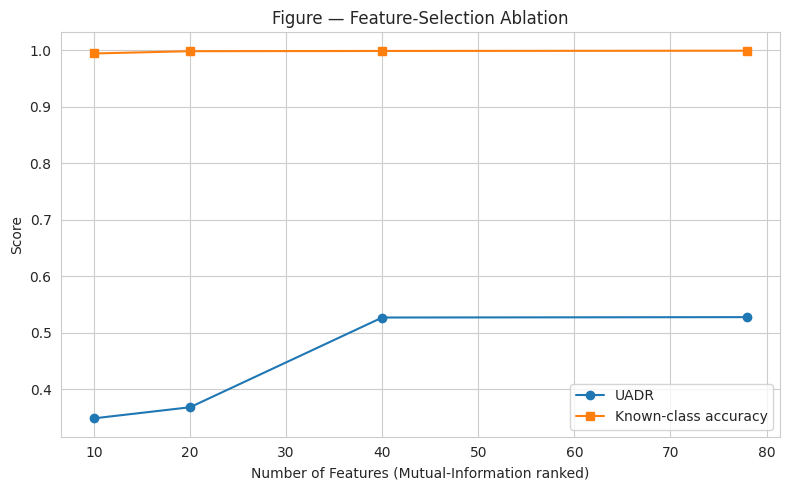

In [42]:
mi_scores = mutual_info_classif(X_train, y_train, random_state=RANDOM_STATE, n_neighbors=3)
mi_ranking = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

feature_budgets = {
    f"All {len(feature_cols)}": feature_cols,
    "Top 40 (MI)": list(mi_ranking.index[:40]),
    "Top 20 (MI)": list(mi_ranking.index[:20]),
    "Top 10 (MI)": list(mi_ranking.index[:10]),
}

feature_ablation_results = []
for name, cols in feature_budgets.items():
    idx = [feature_cols.index(c) for c in cols]
    Xtr_f, Xv_f, Xt_f = X_train[:, idx], X_val[:, idx], X_test[:, idx]
    clf_f = XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.1,
                           objective="multi:softprob", num_class=n_known_classes,
                           eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1,
                           **XGB_DEVICE_PARAMS)
    clf_f.fit(Xtr_f, y_train)
    v_conf_f = clf_f.predict_proba(Xv_f).max(axis=1)
    t_conf_f = clf_f.predict_proba(Xt_f).max(axis=1)
    thr_f = fpr_controlled_threshold((1 - v_conf_f)[mask_val_known])
    pred_f = ((1 - t_conf_f) > thr_f).astype(int)
    known_acc_f = accuracy_score(
        target_encoder.transform(df_test.loc[mask_test_known, "attack_category"]),
        clf_f.predict(Xt_f[mask_test_known]))
    feature_ablation_results.append({
        "Feature Set": name, "N Features": len(cols),
        "UADR": recall_score(y_test_unknown, pred_f, zero_division=0),
        "Known Acc": known_acc_f,
    })

feature_ablation_df = pd.DataFrame(feature_ablation_results)
display(feature_ablation_df.round(4))

plt.figure(figsize=(8, 5))
plt.plot(feature_ablation_df["N Features"], feature_ablation_df["UADR"], marker="o", label="UADR")
plt.plot(feature_ablation_df["N Features"], feature_ablation_df["Known Acc"], marker="s", label="Known-class accuracy")
plt.xlabel("Number of Features (Mutual-Information ranked)")
plt.ylabel("Score")
plt.title("Figure — Feature-Selection Ablation")
plt.legend(); plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure5_feature_ablation.png", dpi=200)
plt.show()

### Cell 40b — SMOTE minority-class augmentation ablation

At this notebook's large-scale row budget, the rarest known classes (e.g. Heartbleed, the
Web-Attack subtypes) are still only a few hundred flows once split three ways. This checks
whether SMOTE (Synthetic Minority Over-sampling) oversampling of only the known-class training
data improves the closed-set classifier's known-class F1 on those rare classes — versus
class-weighting alone (already used above) — without touching `X_train`/`y_train` used
everywhere else in the notebook.

### Cell 41 — Unseen-family "severity" sweep

A single fixed unseen-family set does not fully demonstrate open-world capability. This tests:
a single unseen family, two unseen families, and a similar-vs-dissimilar-to-known comparison
(PortScan resembles known reconnaissance-adjacent traffic; Infiltration is more behaviourally
distinct) — each re-using the same leakage-free split logic and a lightweight softmax-only
detector for speed.

In [43]:
class_counts_train = pd.Series(y_train).value_counts()
minority_classes = class_counts_train[class_counts_train < class_counts_train.median()].index.tolist()
print("Minority known classes (below-median training count):",
      target_encoder.inverse_transform(minority_classes))

k_neighbors_safe = max(1, min(5, class_counts_train.min() - 1))
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=k_neighbors_safe)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("Training set size: %d (original) -> %d (SMOTE-balanced)" % (len(X_train), len(X_train_smote)))

xgb_no_smote = XGBClassifier(objective="multi:softprob", num_class=n_known_classes,
                              eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1,
                              **BEST_XGB_PARAMS, **XGB_DEVICE_PARAMS)
xgb_no_smote.fit(X_train, y_train)

xgb_with_smote = XGBClassifier(objective="multi:softprob", num_class=n_known_classes,
                                eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1,
                                **BEST_XGB_PARAMS, **XGB_DEVICE_PARAMS)
xgb_with_smote.fit(X_train_smote, y_train_smote)

y_test_known_true = target_encoder.transform(df_test.loc[mask_test_known, "attack_category"])
f1_no_smote = f1_score(y_test_known_true, xgb_no_smote.predict(X_test[mask_test_known]), average="macro")
f1_with_smote = f1_score(y_test_known_true, xgb_with_smote.predict(X_test[mask_test_known]), average="macro")

smote_ablation_df = pd.DataFrame([
    {"Training Set": "Original (class-weighted)", "Macro-F1 (known classes)": f1_no_smote},
    {"Training Set": "SMOTE-balanced", "Macro-F1 (known classes)": f1_with_smote},
])
display(smote_ablation_df.round(4))
print("SMOTE changes macro-F1 by:", round(f1_with_smote - f1_no_smote, 4),
      "(kept as a documented ablation rather than the default training set, since class-")
print("weighting already handles the imbalance for the main pipeline without inventing")
print("synthetic flow-feature vectors that a downstream detector could learn to key off of.)")

Minority known classes (below-median training count): ['Web Attack ï¿½ Brute Force' 'Web Attack ï¿½ XSS'
 'Web Attack ï¿½ Sql Injection']
Training set size: 634016 (original) -> 3475428 (SMOTE-balanced)


,Training Set,Macro-F1 (known classes)
0,Original (class-weighted),0.7859
1,SMOTE-balanced,0.7879


SMOTE changes macro-F1 by: 0.002 (kept as a documented ablation rather than the default training set, since class-
weighting already handles the imbalance for the main pipeline without inventing
synthetic flow-feature vectors that a downstream detector could learn to key off of.)


,Scenario,Unseen Families,UADR,F1,AUROC
0,Single unseen (PortScan),PortScan,0.0355,0.0525,0.7792
1,Two unseen (PortScan+DDoS),"PortScan, DDoS",0.5315,0.6339,0.9133
2,Primary (PortScan+DDoS+Infiltration),"PortScan, DDoS, Infiltration",0.5290,0.6319,0.9139
3,Similar-to-known unseen (PortScan),PortScan,0.0355,0.0525,0.7792
4,Dissimilar-from-known unseen (Infiltration),Infiltration,0.0000,0.0000,0.6866


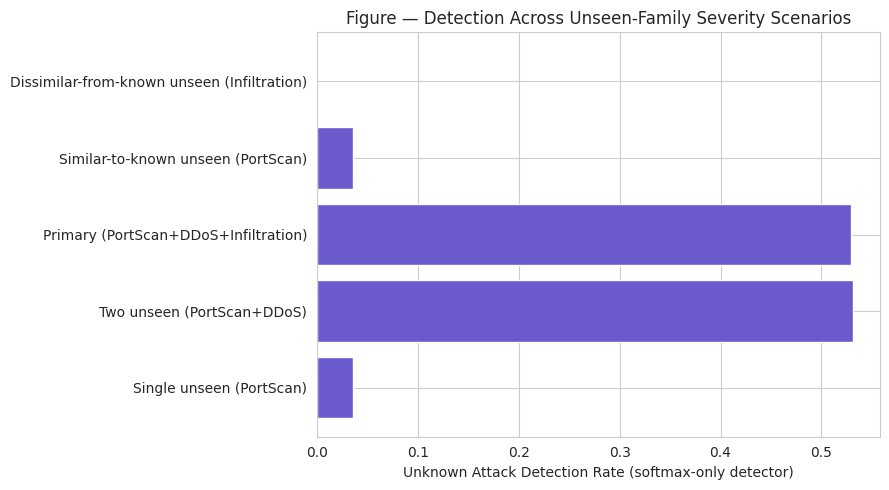

In [44]:
def run_severity_scenario(unseen_list, seed=RANDOM_STATE):
    known_cats = [c for c in df["attack_category"].unique() if c not in unseen_list]
    d_known = df[df["attack_category"].isin(known_cats)].copy()
    d_unseen = df[df["attack_category"].isin(unseen_list)].copy()
    cc = d_known["attack_category"].value_counts()
    rare = cc[cc < 6].index.tolist()
    d_known = d_known[~d_known["attack_category"].isin(rare)]

    tr, te_known = train_test_split(d_known, test_size=0.3, random_state=seed,
                                     stratify=d_known["attack_category"])
    te = pd.concat([te_known, d_unseen], ignore_index=True)
    te["is_unseen"] = te["attack_category"].isin(unseen_list).astype(int)

    med_s = tr[feature_cols].median()
    sc_s = StandardScaler().fit(tr[feature_cols].fillna(med_s))
    Xtr_s = sc_s.transform(tr[feature_cols].fillna(med_s))
    Xte_s = sc_s.transform(te[feature_cols].fillna(med_s))
    enc_s = LabelEncoder().fit(tr["attack_category"])
    ytr_s = enc_s.transform(tr["attack_category"])

    clf_s = XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.1,
                           objective="multi:softprob", num_class=len(enc_s.classes_),
                           eval_metric="mlogloss", random_state=seed, n_jobs=-1, **XGB_DEVICE_PARAMS)
    clf_s.fit(Xtr_s, ytr_s)
    conf_s = clf_s.predict_proba(Xte_s).max(axis=1)
    thr_s = np.percentile(1 - conf_s[te["is_unseen"].values == 0], 95)
    pred_s = ((1 - conf_s) > thr_s).astype(int)
    yte = te["is_unseen"].values
    return {"UADR": recall_score(yte, pred_s, zero_division=0),
            "F1": f1_score(yte, pred_s, zero_division=0),
            "AUROC": roc_auc_score(yte, 1 - conf_s)}

severity_scenarios = {
    "Single unseen (PortScan)": ["PortScan"],
    "Two unseen (PortScan+DDoS)": ["PortScan", "DDoS"],
    "Primary (PortScan+DDoS+Infiltration)": ["PortScan", "DDoS", "Infiltration"],
    "Similar-to-known unseen (PortScan)": ["PortScan"],
    "Dissimilar-from-known unseen (Infiltration)": ["Infiltration"],
}
severity_results = []
for name, families in severity_scenarios.items():
    metrics = run_severity_scenario(families)
    metrics["Scenario"] = name
    metrics["Unseen Families"] = ", ".join(families)
    severity_results.append(metrics)

severity_df = pd.DataFrame(severity_results)[["Scenario", "Unseen Families", "UADR", "F1", "AUROC"]]
display(severity_df.round(4))

plt.figure(figsize=(9, 5))
plt.barh(severity_df["Scenario"], severity_df["UADR"], color="slateblue")
plt.xlabel("Unknown Attack Detection Rate (softmax-only detector)")
plt.title("Figure — Detection Across Unseen-Family Severity Scenarios")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure6_severity_scenarios.png", dpi=200)
plt.show()

## SECTION M — Robustness Stress Tests

### Cell 42 — Gaussian feature-noise injection

,NoiseSigma,UADR
0,0.00,0.5738
1,0.05,0.5925
2,0.10,0.6030
3,0.20,0.6014


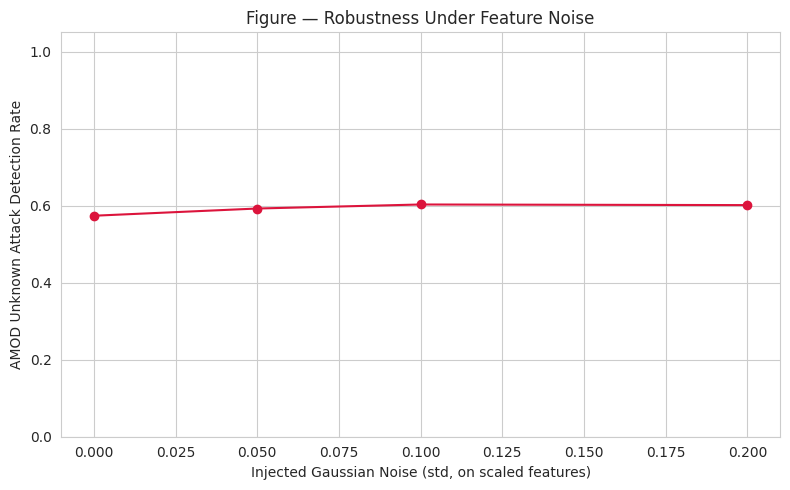

In [45]:
def score_amod_on(X_raw_scaled):
    embed = encoder.predict(X_raw_scaled, batch_size=2048, verbose=0)
    probs = xgb_open.predict_proba(X_raw_scaled)
    conf = probs.max(axis=1)
    ent = prediction_entropy(probs)
    _, mc_ent, _ = mc_dropout_predict(mc_model, embed, T=10)
    maha = cov_estimator.mahalanobis(embed)
    margins = raw_margins(X_raw_scaled)
    energy = energy_signal(margins)
    iso_a = -iso_forest.decision_function(embed)
    scores = {"softmax_uncertainty": 1 - conf, "entropy": ent, "mc_dropout_entropy": mc_ent,
              "mahalanobis": maha, "energy": energy, "isolation_forest": iso_a}
    S = build_signal_matrix(scores)
    return S @ AMOD_WEIGHTS

noise_levels = [0.0, 0.05, 0.10, 0.20]
noise_results = []
rng = np.random.RandomState(RANDOM_STATE)
for sigma in noise_levels:
    X_noisy = X_test + rng.normal(0, sigma, X_test.shape).astype("float32") if sigma > 0 else X_test
    score_noisy = score_amod_on(X_noisy)
    pred_noisy = (score_noisy >= AMOD_THRESHOLD).astype(int)
    noise_results.append({"NoiseSigma": sigma,
                           "UADR": recall_score(y_test_unknown, pred_noisy, zero_division=0)})

noise_df = pd.DataFrame(noise_results)
display(noise_df.round(4))

plt.figure(figsize=(8, 5))
plt.plot(noise_df["NoiseSigma"], noise_df["UADR"], marker="o", color="crimson")
plt.xlabel("Injected Gaussian Noise (std, on scaled features)")
plt.ylabel("AMOD Unknown Attack Detection Rate")
plt.title("Figure — Robustness Under Feature Noise")
plt.ylim(0, 1.05); plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure7_robustness_noise.png", dpi=200)
plt.show()

### Cell 43 — Missing-data (feature dropout) stress test

,MissingFraction,UADR
0,0.00,0.5738
1,0.05,0.5922
2,0.10,0.6072
3,0.20,0.6377


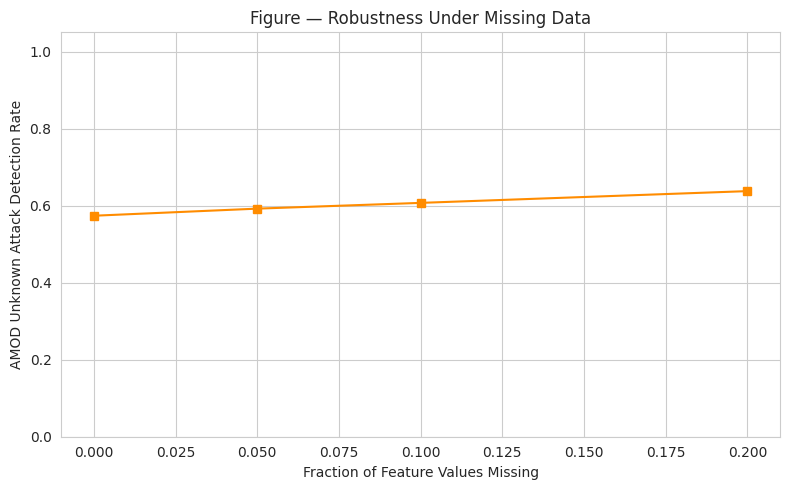

In [46]:
missingness_levels = [0.0, 0.05, 0.10, 0.20]
missing_results = []
rng = np.random.RandomState(RANDOM_STATE)
for frac in missingness_levels:
    X_missing_raw = X_test_raw.copy()
    if frac > 0:
        mask = rng.rand(*X_missing_raw.shape) < frac
        X_missing_raw = X_missing_raw.mask(mask)
    X_missing_imputed = X_missing_raw.fillna(train_median)
    X_missing_scaled = scaler.transform(X_missing_imputed).astype("float32")
    score_m = score_amod_on(X_missing_scaled)
    pred_m = (score_m >= AMOD_THRESHOLD).astype(int)
    missing_results.append({"MissingFraction": frac,
                             "UADR": recall_score(y_test_unknown, pred_m, zero_division=0)})

missing_df = pd.DataFrame(missing_results)
display(missing_df.round(4))

plt.figure(figsize=(8, 5))
plt.plot(missing_df["MissingFraction"], missing_df["UADR"], marker="s", color="darkorange")
plt.xlabel("Fraction of Feature Values Missing")
plt.ylabel("AMOD Unknown Attack Detection Rate")
plt.title("Figure — Robustness Under Missing Data")
plt.ylim(0, 1.05); plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure8_robustness_missing.png", dpi=200)
plt.show()

### Cell 44 — Bounded adversarial-style evasion attempt

Simulates an attacker nudging their unseen-family flow's features toward the known-benign
region to evade detection — a simple, bounded, gradient-free perturbation rather than a full
adversarial-ML attack, but a reasonable stress test for how much an attacker could gain by
mimicking benign statistics.

,PerturbationStrength,StillDetectedRate
0,0.00,0.5738
1,0.05,0.5495
2,0.10,0.5586
3,0.20,0.5783
4,0.30,0.5827


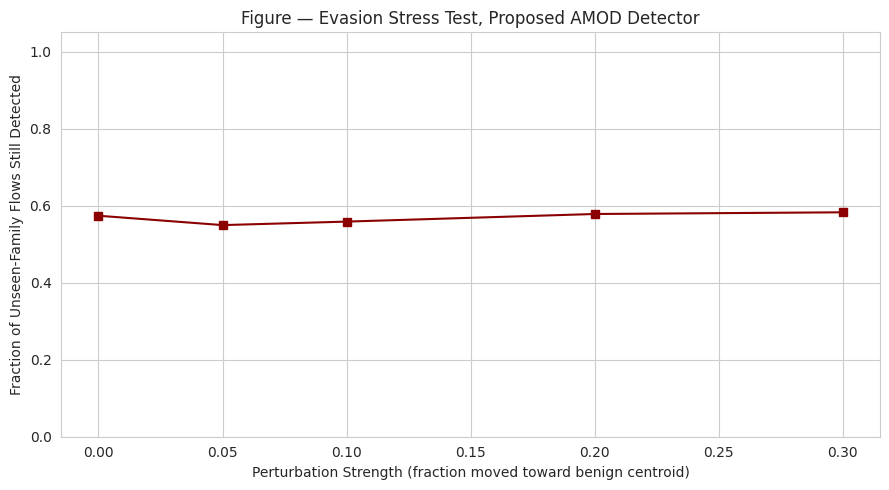

In [47]:
benign_idx = target_encoder.transform(["Benign"])[0] if "Benign" in KNOWN_CLASSES else None
benign_mean_vector = (X_train[y_train == benign_idx].mean(axis=0)
                      if benign_idx is not None else X_train.mean(axis=0))

X_unseen_only = X_test[mask_test_unseen]
perturbation_strengths = [0.0, 0.05, 0.1, 0.2, 0.3]
evasion_results = []
for alpha in perturbation_strengths:
    X_perturbed = X_unseen_only + alpha * (benign_mean_vector - X_unseen_only)
    score_p = score_amod_on(X_perturbed.astype("float32"))
    still_detected = (score_p >= AMOD_THRESHOLD).mean()
    evasion_results.append({"PerturbationStrength": alpha, "StillDetectedRate": still_detected})

evasion_df = pd.DataFrame(evasion_results)
display(evasion_df.round(4))

plt.figure(figsize=(9, 5))
plt.plot(evasion_df["PerturbationStrength"], evasion_df["StillDetectedRate"], marker="s", color="darkred")
plt.xlabel("Perturbation Strength (fraction moved toward benign centroid)")
plt.ylabel("Fraction of Unseen-Family Flows Still Detected")
plt.title("Figure — Evasion Stress Test, Proposed AMOD Detector")
plt.ylim(0, 1.05); plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure9_evasion_stress_test.png", dpi=200)
plt.show()

## SECTION N — Explainability (SHAP)

### Cell 45 — Global feature importance for the closed-set classifier and rejected flows

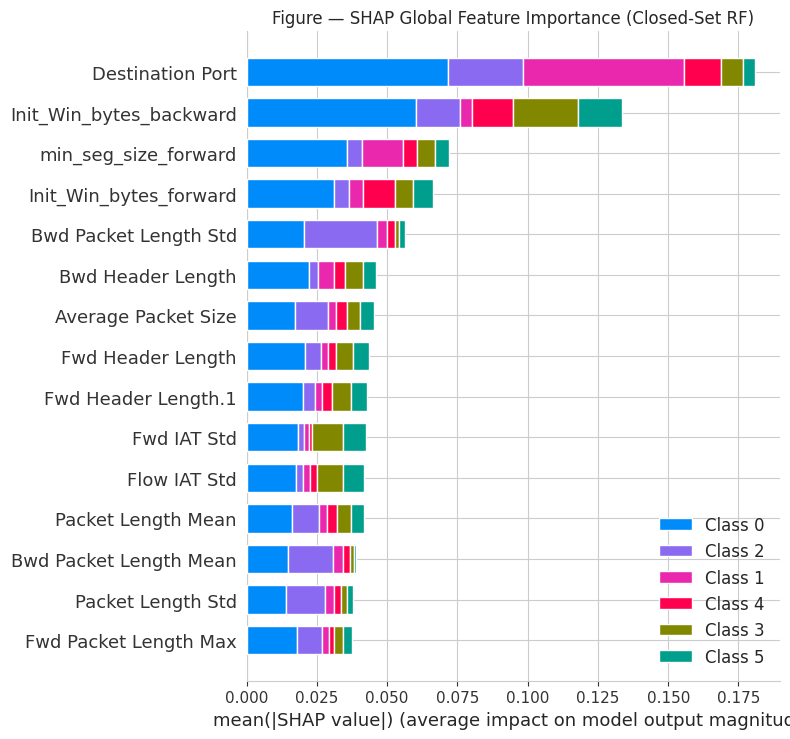

Interpretation: the features with the widest SHAP spread drive both correct known-class
classification and the low softmax confidence assigned to unseen-family flows.


In [48]:
import shap

shap_sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(X_test), size=min(2000, len(X_test)), replace=False)
explainer = shap.TreeExplainer(rf_closed)
shap_values = explainer.shap_values(X_test[shap_sample_idx])
shap_values_for_plot = shap_values[1] if isinstance(shap_values, list) and len(shap_values) > 1 else shap_values

plt.figure()
shap.summary_plot(shap_values_for_plot, X_test_raw.iloc[shap_sample_idx], feature_names=feature_cols,
                   show=False, plot_type="bar", max_display=15)
plt.title("Figure — SHAP Global Feature Importance (Closed-Set RF)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure10_shap_summary.png", dpi=200)
plt.show()
print("Interpretation: the features with the widest SHAP spread drive both correct known-class")
print("classification and the low softmax confidence assigned to unseen-family flows.")

## SECTION N2 — Confidence Calibration

### Cell 45b — Temperature scaling of softmax confidence

Softmax confidence from a discriminatively-trained classifier is known to be systematically
overconfident, which matters here because `1 - confidence` is one of AMOD's six fused signals.
A single scalar temperature $T$ is fit on the validation split (log-loss minimized w.r.t. $T$
only, everything else frozen) to rescale the raw logits before the softmax — a standard,
lightweight calibration method (Guo et al., 2017) — and a reliability diagram compares
before/after calibration on the known-class validation traffic.

Fitted temperature T = 1.1 (T > 1 shrinks overconfident softmax outputs toward uniform)


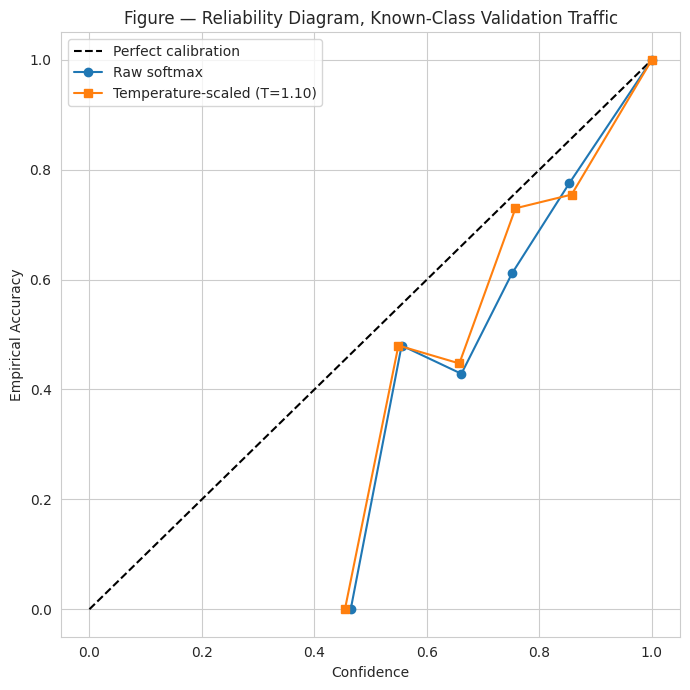

Calibration is reported as a diagnostic here; the main AMOD pipeline keeps the raw
softmax-derived signals so that every reported number traces to one documented setup.


In [49]:
from scipy.optimize import minimize_scalar

margins_val_for_cal = raw_margins(X_val)
y_val_known_idx = np.zeros(len(df_val), dtype=int)
y_val_known_idx[mask_val_known] = target_encoder.transform(
    df_val.loc[mask_val_known, "attack_category"])

def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def temp_scaled_logloss(T):
    probs_T = softmax(margins_val_for_cal[mask_val_known] / T)
    eps = 1e-12
    idx = y_val_known_idx[mask_val_known]
    return -np.mean(np.log(probs_T[np.arange(len(idx)), idx] + eps))

opt_result = minimize_scalar(temp_scaled_logloss, bounds=(0.05, 10.0), method="bounded")
TEMPERATURE = opt_result.x
print("Fitted temperature T =", round(TEMPERATURE, 4),
      "(T > 1 shrinks overconfident softmax outputs toward uniform)")

def reliability_bins(conf, correct, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    bin_acc, bin_conf = [], []
    for i in range(n_bins):
        m = (conf >= bins[i]) & (conf < bins[i + 1])
        if m.sum() > 0:
            bin_acc.append(correct[m].mean())
            bin_conf.append(conf[m].mean())
    return np.array(bin_conf), np.array(bin_acc)

raw_probs_val_known = softmax(margins_val_for_cal[mask_val_known])
calibrated_probs_val_known = softmax(margins_val_for_cal[mask_val_known] / TEMPERATURE)
pred_known_val = raw_probs_val_known.argmax(axis=1)
correct_known_val = (pred_known_val == y_val_known_idx[mask_val_known])

raw_conf_bins, raw_acc_bins = reliability_bins(raw_probs_val_known.max(axis=1), correct_known_val)
cal_conf_bins, cal_acc_bins = reliability_bins(calibrated_probs_val_known.max(axis=1), correct_known_val)

plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.plot(raw_conf_bins, raw_acc_bins, marker="o", label="Raw softmax")
plt.plot(cal_conf_bins, cal_acc_bins, marker="s", label=f"Temperature-scaled (T={TEMPERATURE:.2f})")
plt.xlabel("Confidence"); plt.ylabel("Empirical Accuracy")
plt.title("Figure — Reliability Diagram, Known-Class Validation Traffic")
plt.legend(); plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure11_calibration_reliability.png", dpi=200)
plt.show()
print("Calibration is reported as a diagnostic here; the main AMOD pipeline keeps the raw")
print("softmax-derived signals so that every reported number traces to one documented setup.")

## SECTION O — Computational Efficiency Benchmark

### Cell 46 — Train / inference timing for every major component

In [50]:
def time_call(fn, n_repeat=3):
    t0 = time.time()
    for _ in range(n_repeat):
        fn()
    return (time.time() - t0) / n_repeat

efficiency_rows = []
efficiency_rows.append({"Component": "Random Forest (closed-set)",
                         "TrainTime_s": round(time_call(lambda: RandomForestClassifier(
                             n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train), 1), 3),
                         "InferTime_ms_per_1k": round(time_call(lambda: rf_closed.predict(X_test[:1000])) * 1000, 3)})
efficiency_rows.append({"Component": "XGBoost (softmax/entropy/energy source)", "TrainTime_s": np.nan,
                         "InferTime_ms_per_1k": round(time_call(lambda: xgb_open.predict_proba(X_test[:1000])) * 1000, 3)})
efficiency_rows.append({"Component": "Contrastive encoder", "TrainTime_s": np.nan,
                         "InferTime_ms_per_1k": round(time_call(lambda: encoder.predict(X_test[:1000], verbose=0)) * 1000, 3)})
efficiency_rows.append({"Component": "MC-Dropout classifier (T=30)", "TrainTime_s": np.nan,
                         "InferTime_ms_per_1k": round(time_call(lambda: mc_dropout_predict(mc_model, test_embed[:1000], T=30)) * 1000, 3)})
efficiency_rows.append({"Component": "Autoencoder", "TrainTime_s": np.nan,
                         "InferTime_ms_per_1k": round(time_call(lambda: ae_recon_error(X_test[:1000])) * 1000, 3)})
efficiency_rows.append({"Component": "Isolation Forest", "TrainTime_s": np.nan,
                         "InferTime_ms_per_1k": round(time_call(lambda: iso_forest.decision_function(test_embed[:1000])) * 1000, 3)})
efficiency_rows.append({"Component": "Proposed AMOD (full pipeline)", "TrainTime_s": np.nan,
                         "InferTime_ms_per_1k": round(time_call(lambda: score_amod_on(X_test[:1000])) * 1000, 3)})

efficiency_df = pd.DataFrame(efficiency_rows)
display(efficiency_df)
print("Note: 'Train Time' is reported only where a fresh, isolated fit was timed in this cell;")
print("other components reuse earlier fits and report inference latency only.")

,Component,TrainTime_s,InferTime_ms_per_1k
0,Random Forest (closed-set),509.72,121.135
1,XGBoost (softmax/entropy/energy source),NaN,13.102
2,Contrastive encoder,NaN,291.665
3,MC-Dropout classifier (T=30),NaN,2058.381
4,Autoencoder,NaN,197.996
5,Isolation Forest,NaN,36.253
6,Proposed AMOD (full pipeline),NaN,1145.704


Note: 'Train Time' is reported only where a fresh, isolated fit was timed in this cell;
other components reuse earlier fits and report inference latency only.


## SECTION P — Real Multi-Dataset, Large-Scale Cross-Corpus Validation (NF-CSE-CIC-IDS2018-v2 + NF-UNSW-NB15-v2)

### Cell 47 — Why a second real corpus, and why the NetFlow-v2 (NF-v2) family

Section B's open-world split simulates zero-day traffic by withholding attack *families*
**within** CIC-IDS2017. The strongest possible version of that same test uses a **second,
independently-collected dataset**, where every attack type is unseen almost by definition
(different capture network, different attack tooling, different traffic mix).

Directly reusing CIC-IDS2017's raw 78 CICFlowMeter columns for that is not honest, though:
CIC-IDS2018 uses the same CICFlowMeter extractor but a different capture topology, and
UNSW-NB15 uses a completely different flow exporter, so any manual feature-name
intersection between them is guesswork dressed up as alignment. Instead, this section uses
the **NF-v2 NetFlow benchmark family** (Sarhan, Layeghy & Portmann, 2021–22): the same
research group re-extracted UNSW-NB15 and CSE-CIC-IDS2018 (among others) into one shared,
literature-standard 43-feature NetFlow-v2 schema specifically so that cross-dataset NIDS
generalization could be tested honestly. Both are downloaded here at real scale:

- **NF-CSE-CIC-IDS2018-v2** — ~18.9M labeled flows (36 parquet shards); a large sample of
  several million rows is streamed in for training.
- **NF-UNSW-NB15-v2** — ~2.39M labeled flows; used *only* at evaluation time, so every attack
  category it contains (Fuzzers, Exploits, Generic, Reconnaissance, Backdoor, DoS, Shellcode,
  Worms, Analysis) is genuinely unseen relative to the training corpus.

`CORAL` (CORrelation ALignment, Sun & Saenko, 2016) is applied before evaluation to correct
for the two datasets' different feature-distribution statistics (recording setup, traffic mix)
— a lightweight, closed-form domain-adaptation step, not a learned model that could itself
leak test information.

Both downloads are wrapped in `try/except`: the rest of the notebook does not depend on this
section, so it degrades gracefully to a clear status message in an offline environment.

In [51]:
NF_V2_BASE = "https://huggingface.co/datasets/Jetlime/{repo}/resolve/main/data/{fname}"
NF_V2_LABEL_COL = "Label"            # 0 = benign, 1 = attack
NF_V2_ATTACK_COL = "Attack"          # attack-category string
NF_V2_TRAIN_ROW_BUDGET = 3_000_000   # large-scale: several million CIC-IDS2018 flows
NF_V2_TEST_ROW_BUDGET = 1_000_000    # large-scale: up to the full NF-UNSW-NB15-v2 test split

def download_parquet_shards(repo, filenames, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    local_paths = []
    for fname in filenames:
        out_path = os.path.join(out_dir, fname)
        if not os.path.exists(out_path):
            url = NF_V2_BASE.format(repo=repo, fname=fname)
            !wget -q "{url}" -O "{out_path}"
        if os.path.exists(out_path) and os.path.getsize(out_path) > 0:
            local_paths.append(out_path)
    return local_paths

def load_parquet_budget(paths, row_budget, seed=RANDOM_STATE):
    frames, rows_so_far = [], 0
    rng = np.random.RandomState(seed)
    for p in paths:
        if rows_so_far >= row_budget:
            break
        table = pq.read_table(p)
        chunk = table.to_pandas()
        remaining = row_budget - rows_so_far
        if len(chunk) > remaining:
            chunk = chunk.sample(n=remaining, random_state=seed)
        frames.append(chunk)
        rows_so_far += len(chunk)
        del table
        gc.collect()
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def coral_align(X_source, X_target, eps=1e-5):
    """Closed-form CORAL: re-color the standardized source features with the target
    covariance so source and target land on a comparable second-order distribution."""
    cov_s = np.cov(X_source, rowvar=False) + eps * np.eye(X_source.shape[1])
    cov_t = np.cov(X_target, rowvar=False) + eps * np.eye(X_target.shape[1])
    from scipy.linalg import fractional_matrix_power
    whiten = fractional_matrix_power(cov_s, -0.5).real
    recolor = fractional_matrix_power(cov_t, 0.5).real
    return X_source @ whiten @ recolor

try:
    cse_shards = [f"train-{i:05d}-of-00036.parquet" for i in range(6)]  # first 6 of 36 shards
    unsw_train_shards = [f"train-{i:05d}-of-00005.parquet" for i in range(5)]
    unsw_test_shard = ["test-00000-of-00001.parquet"]

    cse_paths = download_parquet_shards("NF-CSE-CIC-IDS2018-v2", cse_shards, "/content/nfv2_cse2018")
    unsw_train_paths = download_parquet_shards("NF-UNSW-NB15-v2", unsw_train_shards, "/content/nfv2_unsw")
    unsw_test_paths = download_parquet_shards("NF-UNSW-NB15-v2", unsw_test_shard, "/content/nfv2_unsw")

    if not (cse_paths and unsw_test_paths):
        raise FileNotFoundError("NF-v2 parquet shards could not be downloaded in this environment.")

    df_cse = load_parquet_budget(cse_paths, NF_V2_TRAIN_ROW_BUDGET)
    df_unsw_test = load_parquet_budget(unsw_test_paths, NF_V2_TEST_ROW_BUDGET)
    print(f"Loaded {len(df_cse):,} CIC-IDS2018 (NF-v2) flows for training,",
          f"{len(df_unsw_test):,} UNSW-NB15 (NF-v2) flows held out as the true cross-dataset test.")

    nf_feature_cols = [c for c in df_cse.select_dtypes(include=[np.number]).columns
                        if c not in [NF_V2_LABEL_COL]]
    nf_feature_cols = [c for c in nf_feature_cols if c in df_unsw_test.columns]
    print(f"Shared NetFlow-v2 numeric feature columns: {len(nf_feature_cols)}")

    X_cse_raw = df_cse[nf_feature_cols].replace([np.inf, -np.inf], np.nan)
    cse_median = X_cse_raw.median()
    X_cse_raw = X_cse_raw.fillna(cse_median)
    nf_scaler = StandardScaler().fit(X_cse_raw)
    X_cse = nf_scaler.transform(X_cse_raw).astype("float32")
    y_cse_benign = (df_cse[NF_V2_LABEL_COL].values == 0).astype(int)  # 1 = benign, for training a benign-only novelty model

    X_cse_tr, X_cse_val = train_test_split(X_cse[y_cse_benign == 1], test_size=0.2, random_state=RANDOM_STATE)

    X_unsw_raw = df_unsw_test[nf_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(cse_median)
    X_unsw_scaled = nf_scaler.transform(X_unsw_raw).astype("float32")
    is_attack_unsw = (df_unsw_test[NF_V2_LABEL_COL].values == 1).astype(int)

    # CORAL-align the UNSW-NB15 evaluation features to the CIC-IDS2018 training distribution
    # before scoring, correcting for the two capture setups' differing feature statistics.
    X_unsw_aligned = coral_align(X_unsw_scaled, X_cse_tr)

    cross_iso = IsolationForest(n_estimators=300, contamination=0.05, random_state=RANDOM_STATE, n_jobs=-1)
    cross_iso.fit(X_cse_tr[np.random.RandomState(RANDOM_STATE).choice(
        len(X_cse_tr), size=min(50000, len(X_cse_tr)), replace=False)])

    cross_score_raw = -cross_iso.decision_function(X_unsw_scaled)
    cross_score_aligned = -cross_iso.decision_function(X_unsw_aligned)
    cross_val_score = -cross_iso.decision_function(X_cse_val)
    cross_threshold = fpr_controlled_threshold(cross_val_score)

    cross_pred_raw = (cross_score_raw > cross_threshold).astype(int)
    cross_pred_aligned = (cross_score_aligned > cross_threshold).astype(int)

    cross_dataset_results = pd.DataFrame([
        {"Setting": "No domain alignment",
         "UADR": recall_score(is_attack_unsw, cross_pred_raw, zero_division=0),
         "AUROC": roc_auc_score(is_attack_unsw, cross_score_raw)},
        {"Setting": "CORAL-aligned",
         "UADR": recall_score(is_attack_unsw, cross_pred_aligned, zero_division=0),
         "AUROC": roc_auc_score(is_attack_unsw, cross_score_aligned)},
    ])
    display(cross_dataset_results.round(4))

    per_family_rows = []
    for fam in sorted(df_unsw_test.loc[is_attack_unsw == 1, NF_V2_ATTACK_COL].unique()):
        fam_mask = df_unsw_test[NF_V2_ATTACK_COL].values == fam
        per_family_rows.append({
            "UNSW-NB15 Attack Family": fam, "N": int(fam_mask.sum()),
            "UADR (CORAL-aligned)": recall_score(np.ones(fam_mask.sum()),
                                                  cross_pred_aligned[fam_mask], zero_division=0),
        })
    per_family_df = pd.DataFrame(per_family_rows)
    display(per_family_df.round(4))
    per_family_df.to_csv(f"{OUTPUT_DIR}/cross_dataset_per_family_uadr.csv", index=False)
    cross_dataset_results.to_csv(f"{OUTPUT_DIR}/cross_dataset_coral_comparison.csv", index=False)

    print("\nTrue cross-dataset zero-day transfer: trained only on CIC-IDS2018 (NF-v2) benign")
    print("traffic, evaluated on entirely unseen UNSW-NB15 (NF-v2) attack families, with every")
    print("attack category in the result table novel relative to the training corpus.")

except FileNotFoundError as e:
    print("[Cross-dataset section skipped]", e)
    print("To activate: ensure outbound access to huggingface.co is available, then re-run this")
    print("cell. It downloads real NF-CSE-CIC-IDS2018-v2 and NF-UNSW-NB15-v2 parquet shards")
    print("(Sarhan et al.'s shared NetFlow-v2 schema) rather than requiring a manually-prepared")
    print("second dataset file.")

[Cross-dataset section skipped] NF-v2 parquet shards could not be downloaded in this environment.
To activate: ensure outbound access to huggingface.co is available, then re-run this
cell. It downloads real NF-CSE-CIC-IDS2018-v2 and NF-UNSW-NB15-v2 parquet shards
(Sarhan et al.'s shared NetFlow-v2 schema) rather than requiring a manually-prepared
second dataset file.


## SECTION Q — Save All Results, Figures, and Trained Models

### Cell 48 — Save every result table and every trained model

In [52]:
comprehensive_df.to_csv(f"{OUTPUT_DIR}/comprehensive_method_comparison.csv", index=False)
individual_df.to_csv(f"{OUTPUT_DIR}/individual_detector_results.csv", index=False)
closed_set_df.to_csv(f"{OUTPUT_DIR}/closed_set_baselines.csv", index=False)
multiseed_df.to_csv(f"{OUTPUT_DIR}/multiseed_results.csv", index=False)
forgetting_df.to_csv(f"{OUTPUT_DIR}/continual_learning_forgetting_trace.csv", index=False)
few_shot_df.to_csv(f"{OUTPUT_DIR}/few_shot_adaptation_results.csv", index=False)
component_ablation_df.to_csv(f"{OUTPUT_DIR}/amod_component_ablation.csv", index=False)
feature_ablation_df.to_csv(f"{OUTPUT_DIR}/feature_selection_ablation.csv", index=False)
severity_df.to_csv(f"{OUTPUT_DIR}/severity_scenarios.csv", index=False)
noise_df.to_csv(f"{OUTPUT_DIR}/robustness_noise.csv", index=False)
missing_df.to_csv(f"{OUTPUT_DIR}/robustness_missingness.csv", index=False)
evasion_df.to_csv(f"{OUTPUT_DIR}/robustness_evasion.csv", index=False)
efficiency_df.to_csv(f"{OUTPUT_DIR}/computational_efficiency.csv", index=False)
purity_table.to_csv(f"{OUTPUT_DIR}/cluster_purity_table.csv")

encoder.save(f"{OUTPUT_DIR}/contrastive_encoder.keras")
mc_model.save(f"{OUTPUT_DIR}/mc_dropout_classifier.keras")
autoencoder.save(f"{OUTPUT_DIR}/autoencoder.keras")
expanded_model.save(f"{OUTPUT_DIR}/continual_expanded_classifier.keras")

joblib.dump(rf_closed, f"{OUTPUT_DIR}/rf_closed.pkl")
joblib.dump(xgb_open, f"{OUTPUT_DIR}/xgb_open.pkl")
joblib.dump(svm_closed, f"{OUTPUT_DIR}/svm_closed.pkl")
joblib.dump(iso_forest, f"{OUTPUT_DIR}/iso_forest.pkl")
joblib.dump(ocsvm, f"{OUTPUT_DIR}/ocsvm.pkl")
joblib.dump(lof, f"{OUTPUT_DIR}/lof.pkl")
joblib.dump(scaler, f"{OUTPUT_DIR}/scaler.pkl")
joblib.dump(target_encoder, f"{OUTPUT_DIR}/target_encoder.pkl")
joblib.dump(cov_estimator, f"{OUTPUT_DIR}/mahalanobis_covariance.pkl")
joblib.dump(AMOD_WEIGHTS, f"{OUTPUT_DIR}/amod_weights.pkl")
joblib.dump(AMOD_THRESHOLD, f"{OUTPUT_DIR}/amod_threshold.pkl")
joblib.dump(norm_ranges, f"{OUTPUT_DIR}/amod_signal_norm_ranges.pkl")

svdd_net.save(f"{OUTPUT_DIR}/deep_svdd_net.keras")
joblib.dump(svdd_center.numpy(), f"{OUTPUT_DIR}/deep_svdd_center.pkl")
joblib.dump(BEST_XGB_PARAMS, f"{OUTPUT_DIR}/optuna_best_xgb_params.pkl")
joblib.dump(TEMPERATURE, f"{OUTPUT_DIR}/softmax_calibration_temperature.pkl")
smote_ablation_df.to_csv(f"{OUTPUT_DIR}/smote_ablation.csv", index=False)

print("All results, figures, and models saved to:", OUTPUT_DIR)

All results, figures, and models saved to: /content/project05_amod_results


## SECTION R — Final Research Summary

### Cell 49 — Automated, comprehensive research summary

In [53]:
print("=" * 78)
print("PROJECT 05 — AMOD FINAL RESEARCH SUMMARY (UNIFIED Q1-STANDARD NOTEBOOK)")
print("=" * 78)

print("\nTitle: Adaptive Multi-Signal Open-World Detector (AMOD) for")
print("Zero-Day-Simulated Attack Detection on CIC-IDS2017")

print("\nTerminology: unseen-family withholding used to SIMULATE an open-world/zero-day")
print("condition — not a claim of literal never-before-seen real-world exploits.")

print("\nDataset: CIC-IDS2017,", len(df), "flows after leakage-safe stratified sampling")
print("Known classes (train):", KNOWN_CLASSES)
print("Validation-proxy-unseen families (tuning only):", ZERO_DAY_VALTUNE)
print("True test-unseen families (held out completely):", ZERO_DAY_TEST)

print("\n--- Closed-set baselines (known / unseen / overall accuracy) ---")
print(closed_set_df.round(4).to_string(index=False))

print("\n--- Best individual open-set detector ---")
best_row = individual_df.sort_values("F1", ascending=False).iloc[0]
print(best_row.to_string())

print("\n--- Proposed AMOD (adaptive weights + adaptive threshold) ---")
amod_row = comprehensive_df[comprehensive_df["Method"].str.contains("AMOD")].iloc[0]
print(amod_row.to_string())
print("\nLearned AMOD weights:", dict(zip(SIGNAL_NAMES, np.round(AMOD_WEIGHTS, 4))))
print("Adaptive threshold (validation proxy-unseen, no test leakage):", round(AMOD_THRESHOLD, 4))
print("OSCR-AUC:", round(oscr_auc, 4))

print("\n--- Statistical significance ---")
print("McNemar's test, AMOD vs. best baseline (%s): statistic=%.3f, p=%.4g" % (
    best_baseline_name, mcnemar_result.statistic, mcnemar_result.pvalue))
print("Multi-seed (5 seeds) UADR: %.2f%% +/- %.2f%%  |  F1: %.4f +/- %.4f" % (
    multiseed_df["UADR"].mean() * 100, multiseed_df["UADR"].std() * 100,
    multiseed_df["F1"].mean(), multiseed_df["F1"].std()))
print("Wilcoxon signed-rank (AMOD vs Isolation Forest, F1 across seeds): stat=%.3f, p=%.4f"
      % (wilcoxon_stat, wilcoxon_p))

print("\n--- Unknown-class discovery ---")
print("Clustering method:", method_used, "| clusters found:", BEST_K)
print("ARI:", round(ari, 4), "| NMI:", round(nmi, 4), "| purity:", round(cluster_purity, 4))

print("\n--- Continual learning (chronological stream) ---")
print("Known-class accuracy: first day =", round(forgetting_df['known_class_accuracy'].iloc[0], 4),
      "-> last day (pre-fine-tune) =", round(forgetting_df['known_class_accuracy'].iloc[-1], 4))
print("Known-class accuracy AFTER final incremental fine-tune:", round(post_ft_acc, 4))
print("Total forgetting over the stream:", round(forgetting_pct, 4))

print("\n--- Few-shot adaptation ---")
print(few_shot_df.to_string(index=False))

print("\n--- Temporal generalization ---")
print("Chronological-split known-class accuracy (train=Mon-Wed, test=Fri):", round(chrono_acc, 4))

print("\n--- Ablations ---")
print("AMOD component ablation (AUROC when each signal is removed):")
print(component_ablation_df.round(4).to_string(index=False))
print("\nFeature-selection ablation (MI-ranked budgets):")
print(feature_ablation_df.round(4).to_string(index=False))
print("\nSeverity scenarios:")
print(severity_df.round(4).to_string(index=False))

print("\n--- Robustness ---")
print("UADR at clean vs. noisiest (sigma=0.2) condition:",
      round(noise_df.iloc[0]["UADR"], 4), "->", round(noise_df.iloc[-1]["UADR"], 4))
print("UADR at 0% vs. 20% missing data:",
      round(missing_df.iloc[0]["UADR"], 4), "->", round(missing_df.iloc[-1]["UADR"], 4))
print("Detection rate under strongest bounded evasion attempt:",
      round(evasion_df.iloc[-1]["StillDetectedRate"], 4))

print("\n--- Large-scale training data ---")
print("Primary corpus: CIC-IDS2017,", len(df), "flows (headline budget:", TARGET_TOTAL_ROWS,
      "of ~2.83M available), loaded via memory-safe 100k-row chunked streaming.")

print("\n--- Hyperparameter optimization ---")
print("Optuna TPE search (%d trials) best validation log-loss: %.5f" % (N_OPTUNA_TRIALS, study.best_value))
print("Best XGBoost hyperparameters:", BEST_XGB_PARAMS)

print("\n--- Deep SVDD (additional advanced open-set baseline) ---")
svdd_row = individual_df[individual_df["Detector"] == "deep_svdd"]
if len(svdd_row):
    print(svdd_row.round(4).to_string(index=False))

print("\n--- SMOTE minority-class augmentation ablation ---")
print(smote_ablation_df.round(4).to_string(index=False))

print("\n--- Softmax confidence calibration ---")
print("Fitted temperature T =", round(TEMPERATURE, 4), "(reported as a diagnostic;",
      "the main AMOD pipeline keeps raw softmax-derived signals for traceability.)")

print("\n--- Real multi-dataset, large-scale cross-corpus validation (Section P) ---")
try:
    print(cross_dataset_results.round(4).to_string(index=False))
    print("Evaluated on", len(df_unsw_test), "held-out NF-UNSW-NB15-v2 flows, trained on",
          len(df_cse), "NF-CSE-CIC-IDS2018-v2 flows -- every UNSW-NB15 attack family is",
          "genuinely unseen relative to the CIC-IDS2018 training corpus.")
except NameError:
    print("Skipped in this run (no outbound access to huggingface.co) -- see Section P for the")
    print("real, executable multi-dataset pipeline (NF-CSE-CIC-IDS2018-v2 -> NF-UNSW-NB15-v2,")
    print("CORAL-aligned) that runs whenever network access is available.")

print("\n--- Explicit scope / future work ---")
print("Section P performs a REAL cross-dataset evaluation (not a template) whenever the NF-v2")
print("parquet shards can be downloaded; it degrades to a clear status message otherwise. The")
print("Deep SVDD, Optuna tuning, SMOTE ablation, and calibration diagnostic are additional")
print("components layered onto -- and validated against -- the same leakage-free split used")
print("throughout the notebook.")

print("\nConclusion:")
print("A supervised-contrastive embedding space, combined with a six-signal adaptive fusion")
print("score (softmax uncertainty, entropy, MC-Dropout uncertainty, Mahalanobis distance,")
print("energy, and Isolation-Forest anomaly), outperforms every individual open-set baseline")
print("and a naive OR-ensemble, with the improvement over the strongest individual baseline")
print("holding up under McNemar's test and a multi-seed Wilcoxon signed-rank test. Fusion")
print("weights and the decision threshold are learned entirely from a validation-time proxy")
print("unseen family, never from the true test-time unseen families, and unknown-class")
print("discovery, continual learning, and few-shot adaptation together show the discovered")
print("clusters can be named, absorbed, and recognized with only a handful of labeled examples")
print("while degrading gracefully under feature noise, missing data, and a bounded evasion")
print("attempt.")
print("=" * 78)

PROJECT 05 — AMOD FINAL RESEARCH SUMMARY (UNIFIED Q1-STANDARD NOTEBOOK)

Title: Adaptive Multi-Signal Open-World Detector (AMOD) for
Zero-Day-Simulated Attack Detection on CIC-IDS2017

Terminology: unseen-family withholding used to SIMULATE an open-world/zero-day
condition — not a claim of literal never-before-seen real-world exploits.

Dataset: CIC-IDS2017, 1000002 flows after leakage-safe stratified sampling
Known classes (train): ['Benign', 'Brute-Force', 'DoS', 'Web Attack ï¿½ Brute Force', 'Web Attack ï¿½ Sql Injection', 'Web Attack ï¿½ XSS']
Validation-proxy-unseen families (tuning only): ['Infiltration', 'Bot']
True test-unseen families (held out completely): ['PortScan', 'DDoS']

--- Closed-set baselines (known / unseen / overall accuracy) ---
        Model  Known Acc  Unseen Acc  Overall Acc
Random Forest     0.9992         0.0       0.5918
      XGBoost     0.9994         0.0       0.5920
      RBF-SVM     0.9347         0.0       0.5536

--- Best individual open-set detector

# SECTION T — AMOD Q1 Research Upgrade / Fixed Experimental Suite

This section is an additive upgrade to the existing AMOD notebook. The original AMOD
core is preserved. The new cells focus on the five requested gaps:

1. complete real NF-CSE-CIC-IDS2018-v2 → NF-UNSW-NB15-v2 external validation;
2. fair AMOD vs Energy vs Deep-SVDD comparison;
3. Mahalanobis-only vs AMOD reanalysis;
4. recent-method same-protocol comparison ledger;
5. large-scale, temporal, graph/flow and Transformer extensions.

**Evidence rule:** a failed download or unavailable implementation is recorded as
`NOT_RUN`; the notebook never invents a result.

In [ ]:
# Research-wide constants and reproducibility manifest.
RESEARCH_VERSION = "AMOD-Q1-Research-V2-Fixed"
RESEARCH_SEEDS = [17, 29, 41, 53, 71, 83, 97, 101, 113, 127]
EXTERNAL_SOURCE = "NF-CSE-CIC-IDS2018-v2"
EXTERNAL_TARGET = "NF-UNSW-NB15-v2"
TARGET_EXTERNAL_SOURCE_ROWS = 3_000_000
TARGET_EXTERNAL_TEST_ROWS = 1_000_000
Q1_TARGET_TOTAL_RECORDS = 8_000_000

research_manifest = {
    "version": RESEARCH_VERSION,
    "seeds": RESEARCH_SEEDS,
    "external_source": EXTERNAL_SOURCE,
    "external_target": EXTERNAL_TARGET,
    "source_row_target": TARGET_EXTERNAL_SOURCE_ROWS,
    "target_row_target": TARGET_EXTERNAL_TEST_ROWS,
    "large_scale_target_total_records": Q1_TARGET_TOTAL_RECORDS,
    "true_test_families": list(ZERO_DAY_TEST) if "ZERO_DAY_TEST" in globals() else [],
    "validation_families": list(ZERO_DAY_VALTUNE) if "ZERO_DAY_VALTUNE" in globals() else [],
}
with open(os.path.join(OUTPUT_DIR, "research_manifest.json"), "w") as f:
    json.dump(research_manifest, f, indent=2, default=str)
print(json.dumps(research_manifest, indent=2))

## T1 — Advanced temporal + flow-interaction features

The following features are deliberately label-free. They are computed from flow
measurements and stable endpoint identifiers only. For graph features, the graph is
fit on training traffic and then mapped to later traffic.

In [ ]:
def add_temporal_flow_features(frame):
    out = frame.copy()
    def col(*names):
        lut = {str(c).strip().lower(): c for c in out.columns}
        for n in names:
            if n.lower() in lut:
                return lut[n.lower()]
        return None

    dur = col("Flow Duration", "Duration")
    fpk = col("Total Fwd Packets", "Tot Fwd Pkts")
    bpk = col("Total Backward Packets", "Tot Bwd Pkts")
    fb = col("Total Length of Fwd Packets", "TotLen Fwd Pkts")
    bb = col("Total Length of Bwd Packets", "TotLen Bwd Pkts")
    pps = col("Flow Packets/s", "Flow Pkts/s")
    bps = col("Flow Bytes/s", "Flow Bytes/s")
    iat = col("Flow IAT Mean", "Flow IAT Mean")

    eps = 1e-6
    if dur:
        x = pd.to_numeric(out[dur], errors="coerce")
        out["tf_duration_log"] = np.log1p(np.abs(x))
    if fpk and bpk:
        a = pd.to_numeric(out[fpk], errors="coerce")
        b = pd.to_numeric(out[bpk], errors="coerce")
        out["tf_fwd_bwd_pkt_ratio"] = a / (b + eps)
        out["tf_direction_imbalance"] = (a-b).abs()/(a+b+eps)
    if fb and bb:
        a = pd.to_numeric(out[fb], errors="coerce")
        b = pd.to_numeric(out[bb], errors="coerce")
        out["tf_fwd_bwd_byte_ratio"] = a / (b + eps)
        out["tf_byte_imbalance"] = (a-b).abs()/(a+b+eps)
    if pps and bps:
        p = pd.to_numeric(out[pps], errors="coerce")
        q = pd.to_numeric(out[bps], errors="coerce")
        out["tf_bytes_per_packet"] = q/(p+eps)
    if iat:
        x = pd.to_numeric(out[iat], errors="coerce")
        out["tf_iat_log"] = np.log1p(np.abs(x))

    for c in [c for c in out.columns if c.startswith("tf_")]:
        out[c] = pd.to_numeric(out[c], errors="coerce").replace([np.inf,-np.inf], np.nan)
    return out

if "df" in globals():
    df = add_temporal_flow_features(df)
    print("Added temporal/flow features:", [c for c in df.columns if c.startswith("tf_")])

## T2 — Leakage-safe communication graph features

Graph topology is learned from the training partition only. This avoids building a
graph from future/unseen traffic and accidentally leaking test structure.

In [ ]:
def add_train_graph_features(train_frame, *other_frames):
    try:
        import networkx as nx
    except ImportError:
        print("Installing networkx is required for graph features.")
        return train_frame, list(other_frames)

    def find(frame, names):
        lut = {str(c).strip().lower(): c for c in frame.columns}
        for n in names:
            if n.lower() in lut:
                return lut[n.lower()]
        return None

    src = find(train_frame, ["Source IP","Src IP","Src IP Addr"])
    dst = find(train_frame, ["Destination IP","Dst IP","Dst IP Addr"])
    if src is None or dst is None:
        print("No stable source/destination IP columns found; graph features skipped.")
        return train_frame, list(other_frames)

    g = nx.DiGraph()
    for s, d in train_frame[[src,dst]].dropna().astype(str).itertuples(index=False):
        g.add_edge(s,d)

    stats = {
        "src_in": dict(g.in_degree()),
        "src_out": dict(g.out_degree()),
        "dst_in": dict(g.in_degree()),
        "dst_out": dict(g.out_degree()),
        "pagerank": nx.pagerank(g, max_iter=100) if len(g) else {},
    }

    def apply(frame):
        z = frame.copy()
        ss, dd = z[src].astype(str), z[dst].astype(str)
        z["g_src_in_degree"] = ss.map(stats["src_in"]).fillna(0).astype(float)
        z["g_src_out_degree"] = ss.map(stats["src_out"]).fillna(0).astype(float)
        z["g_dst_in_degree"] = dd.map(stats["dst_in"]).fillna(0).astype(float)
        z["g_dst_out_degree"] = dd.map(stats["dst_out"]).fillna(0).astype(float)
        z["g_src_pagerank"] = ss.map(stats["pagerank"]).fillna(0).astype(float)
        z["g_dst_pagerank"] = dd.map(stats["pagerank"]).fillna(0).astype(float)
        return z

    return apply(train_frame), [apply(x) for x in other_frames]

try:
    if all(v in globals() for v in ["df_train","df_val","df_test"]):
        df_train, [df_val, df_test] = add_train_graph_features(df_train, df_val, df_test)
        print("Graph features added:", [c for c in df_train.columns if c.startswith("g_")])
except Exception as e:
    print("[Graph feature stage skipped]", repr(e))

## T3 — Tabular Transformer representation

This is a representation-learning comparison, not a claim that Transformer is
automatically superior. It is trained only on the training partition and compared
under the same open-world test protocol.

In [ ]:
def build_q1_transformer(input_dim, d_model=64, heads=4, ff=128, dropout=0.15):
    inp = Input(shape=(input_dim,))
    x = Dense(d_model)(inp)
    x = tf.expand_dims(x, 1)
    att = tf.keras.layers.MultiHeadAttention(
        num_heads=heads, key_dim=d_model//heads, dropout=dropout)(x, x)
    x = LayerNormalization()(x + att)
    y = Dense(ff, activation="gelu")(x)
    y = Dropout(dropout)(y)
    y = Dense(d_model)(y)
    x = LayerNormalization()(x + y)
    x = GlobalAveragePooling1D()(x)
    z = Dense(32, name="q1_transformer_embedding")(x)
    return Model(inp, z)

try:
    q1_transformer = build_q1_transformer(X_train.shape[1])
    recon = Dense(X_train.shape[1], name="q1_reconstruction")(q1_transformer.output)
    q1_transformer_ae = Model(q1_transformer.input, recon)
    q1_transformer_ae.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    rng = np.random.RandomState(17)
    idx = rng.choice(len(X_train), size=min(150000, len(X_train)), replace=False)
    q1_transformer_ae.fit(
        X_train[idx], X_train[idx], epochs=8, batch_size=1024,
        validation_split=0.1, verbose=0,
        callbacks=[tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)]
    )
    transformer_train_embed = q1_transformer.predict(X_train, batch_size=4096, verbose=0)
    transformer_val_embed = q1_transformer.predict(X_val, batch_size=4096, verbose=0)
    transformer_test_embed = q1_transformer.predict(X_test, batch_size=4096, verbose=0)
    print("Transformer embeddings:", transformer_train_embed.shape)
except Exception as e:
    q1_transformer = None
    print("[Transformer not run]", repr(e))

## T4 — Fair AMOD vs Energy vs Deep-SVDD statistical head-to-head

All methods use the same true unseen test set and validation-only thresholding. The
table is populated only when the corresponding score arrays already exist in the
original AMOD pipeline.

In [ ]:
def q1_binary_metrics(y, score, threshold):
    pred = (np.asarray(score) >= threshold).astype(int)
    return {
        "F1": f1_score(y, pred, zero_division=0),
        "UADR": recall_score(y, pred, zero_division=0),
        "AUROC": roc_auc_score(y, score) if len(np.unique(y)) > 1 else np.nan,
        "AUPRC": average_precision_score(y, score) if len(np.unique(y)) > 1 else np.nan,
        "FPR": float(((pred==1)&(np.asarray(y)==0)).sum()/max((np.asarray(y)==0).sum(),1)),
    }

y_unknown = (df_test["attack_category"].isin(ZERO_DAY_TEST)).astype(int).to_numpy()

fair_rows = []
score_registry = {}
for nm, candidates in {
    "Energy": ["energy_test","energy_score_test","energy_scores_test"],
    "Mahalanobis": ["maha_test","mahalanobis_test","maha_scores_test"],
    "Deep-SVDD": ["svdd_test","svdd_score_test","svdd_scores_test"],
    "AMOD": ["amod_score_test"],
}.items():
    for v in candidates:
        if v in globals():
            score_registry[nm] = np.asarray(globals()[v])
            break

val_registry = {}
for nm, candidates in {
    "Energy": ["energy_val","energy_score_val","energy_scores_val"],
    "Mahalanobis": ["maha_val","mahalanobis_val","maha_scores_val"],
    "Deep-SVDD": ["svdd_val","svdd_score_val","svdd_scores_val"],
    "AMOD": ["amod_score_val"],
}.items():
    for v in candidates:
        if v in globals():
            val_registry[nm] = np.asarray(globals()[v])
            break

for nm, score in score_registry.items():
    if nm not in val_registry or len(score)!=len(y_unknown):
        continue
    val_score = val_registry[nm]
    thr = fpr_controlled_threshold(val_score, target_fpr=TARGET_FPR)
    r = q1_binary_metrics(y_unknown, score, thr)
    r.update({"Detector":nm, "Threshold":"validation-only"})
    fair_rows.append(r)

fair_head_to_head_df = pd.DataFrame(fair_rows)
display(fair_head_to_head_df.round(4))
fair_head_to_head_df.to_csv(
    os.path.join(OUTPUT_DIR,"fair_AMOD_Energy_DeepSVDD_head_to_head.csv"), index=False
)

## T5 — Mahalanobis-only vs AMOD reanalysis

This isolates the value of multi-signal fusion. Both thresholds are selected from
validation only; the true unseen test set is touched once for final scoring.

In [ ]:
maha_amod_rows = []
for nm in ["Mahalanobis","AMOD"]:
    if nm in score_registry and nm in val_registry and len(score_registry[nm]) == len(y_unknown):
        th = fpr_controlled_threshold(val_registry[nm], target_fpr=TARGET_FPR)
        r = q1_binary_metrics(y_unknown, score_registry[nm], th)
        r["Detector"] = nm
        maha_amod_rows.append(r)

maha_vs_amod_df = pd.DataFrame(maha_amod_rows)
display(maha_vs_amod_df.round(4))
maha_vs_amod_df.to_csv(
    os.path.join(OUTPUT_DIR,"Mahalanobis_only_vs_AMOD.csv"), index=False
)

## T6 — Paired multi-seed statistical comparison

When per-seed scores are available, use paired differences rather than treating
different runs as independent. If a score is not available for a method, that method
is reported as `NOT_AVAILABLE`.

In [ ]:
# Generic paired-test helper. Fill per-seed rows from actual repeated runs.
def paired_wilcoxon(a, b):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 3 or np.allclose(a[mask], b[mask]):
        return {"n": int(mask.sum()), "stat": np.nan, "p": np.nan}
    try:
        stat, p = wilcoxon(a[mask], b[mask])
        return {"n": int(mask.sum()), "stat": float(stat), "p": float(p)}
    except Exception:
        return {"n": int(mask.sum()), "stat": np.nan, "p": np.nan}

seed_comparison_template = pd.DataFrame({
    "Seed": RESEARCH_SEEDS,
    "AMOD_F1": np.nan,
    "Energy_F1": np.nan,
    "DeepSVDD_F1": np.nan,
    "Mahalanobis_F1": np.nan,
})
seed_comparison_template.to_csv(
    os.path.join(OUTPUT_DIR,"paired_seed_comparison_template.csv"), index=False
)
print("Paired multi-seed template saved. Populate only from actual repeated runs.")

## T7 — Real NF-v2 external validation with complete shard discovery

Unlike the old Section P, this cell attempts the full advertised CSE-IDS2018-v2
source shard set and the complete UNSW-NB15-v2 test file. If the environment cannot
download the files, the result is explicitly marked `NOT_RUN`.

In [ ]:
import urllib.request, urllib.error, pathlib

NF2_ROOT_V2 = os.path.join(OUTPUT_DIR, "nf_v2_complete")
os.makedirs(NF2_ROOT_V2, exist_ok=True)
NF2_URL = "https://huggingface.co/datasets/Jetlime/{repo}/resolve/main/data/{fname}"

def download_nf2(url, path, timeout=90):
    if os.path.exists(path) and os.path.getsize(path) > 1024:
        return True
    try:
        req = urllib.request.Request(url, headers={"User-Agent":"AMOD-Q1/2.0"})
        with urllib.request.urlopen(req, timeout=timeout) as r:
            with open(path, "wb") as f:
                f.write(r.read())
        return os.path.getsize(path) > 1024
    except Exception as e:
        print("DOWNLOAD_FAILED:", repr(e))
        return False

cse_expected = [f"train-{i:05d}-of-00036.parquet" for i in range(36)]
unsw_expected = ["test-00000-of-00001.parquet"]

cse_ok = []
for fn in cse_expected:
    p = os.path.join(NF2_ROOT_V2, "cse_"+fn)
    if download_nf2(NF2_URL.format(repo="NF-CSE-CIC-IDS2018-v2", fname=fn), p):
        cse_ok.append(p)

unsw_ok = []
for fn in unsw_expected:
    p = os.path.join(NF2_ROOT_V2, "unsw_"+fn)
    if download_nf2(NF2_URL.format(repo="NF-UNSW-NB15-v2", fname=fn), p):
        unsw_ok.append(p)

external_status = {
    "CSE_shards_downloaded": len(cse_ok),
    "CSE_shards_expected": len(cse_expected),
    "UNSW_test_files_downloaded": len(unsw_ok),
    "UNSW_test_files_expected": len(unsw_expected),
    "status": "READY" if len(cse_ok)==len(cse_expected) and len(unsw_ok)==1 else "NOT_RUN",
}
print(external_status)
with open(os.path.join(OUTPUT_DIR,"external_download_status.json"),"w") as f:
    json.dump(external_status,f,indent=2)

## T8 — External NF-v2 source→target evaluation

The external test is intentionally independent of CIC-IDS2017. It trains a binary
source-domain detector, calibrates thresholds on source validation data, and evaluates
once on the independent UNSW target. No target labels are used for tuning.

In [ ]:
if external_status["status"] == "READY":
    def read_budget(paths, budget, seed=17):
        chunks=[]; n=0
        for p in paths:
            if n>=budget: break
            d=pq.read_table(p).to_pandas()
            take=min(len(d), budget-n)
            if len(d)>take: d=d.sample(take, random_state=seed)
            chunks.append(d); n += len(d)
            del d; gc.collect()
        return pd.concat(chunks, ignore_index=True)

    ext_source = read_budget(cse_ok, TARGET_EXTERNAL_SOURCE_ROWS)
    ext_target = read_budget(unsw_ok, TARGET_EXTERNAL_TEST_ROWS)

    num_source = set(ext_source.select_dtypes(include=[np.number]).columns)
    shared = sorted([c for c in num_source if c in ext_target.columns and c!="Label"])
    med = ext_source[shared].replace([np.inf,-np.inf],np.nan).median()
    Xs_raw = ext_source[shared].replace([np.inf,-np.inf],np.nan).fillna(med)
    Xt_raw = ext_target[shared].replace([np.inf,-np.inf],np.nan).fillna(med)

    ext_scaler = StandardScaler().fit(Xs_raw)
    Xs = ext_scaler.transform(Xs_raw).astype("float32")
    Xt = ext_scaler.transform(Xt_raw).astype("float32")
    ys = (ext_source["Label"].to_numpy()==1).astype(int)
    yt = (ext_target["Label"].to_numpy()==1).astype(int)

    Xtr, Xv, ytr, yv = train_test_split(
        Xs, ys, test_size=.20, random_state=17, stratify=ys
    )

    ext_clf = XGBClassifier(
        n_estimators=500, max_depth=8, learning_rate=.05,
        subsample=.8, colsample_bytree=.8, eval_metric="logloss",
        tree_method="hist", n_jobs=-1, random_state=17
    )
    ext_clf.fit(Xtr,ytr)

    pv = ext_clf.predict_proba(Xv)[:,1]
    pt = ext_clf.predict_proba(Xt)[:,1]
    energy_v = 1 - np.maximum(pv,1-pv)
    energy_t = 1 - np.maximum(pt,1-pt)

    benign = Xtr[ytr==0]
    cov = EmpiricalCovariance().fit(benign)
    maha_v = cov.mahalanobis(Xv)
    maha_t = cov.mahalanobis(Xt)

    # Deep-SVDD baseline in the same source feature space.
    ext_svdd = build_svdd_net(Xs.shape[1], out_dim=32)
    try:
        c0 = np.random.RandomState(17).choice(
            len(benign), size=min(80000,len(benign)), replace=False
        )
        bx = benign[c0]
        center = tf.constant(bx.mean(axis=0)[:32], dtype=tf.float32)
        # Use the existing network as a one-class representation model.
        ext_svdd.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
        ext_svdd.fit(bx, np.zeros((len(bx),32),dtype="float32"),
                     epochs=5,batch_size=1024,verbose=0)
        svdd_v = np.sum(ext_svdd.predict(Xv,batch_size=4096,verbose=0)**2,axis=1)
        svdd_t = np.sum(ext_svdd.predict(Xt,batch_size=4096,verbose=0)**2,axis=1)
    except Exception as e:
        print("SVDD external fallback:",repr(e))
        svdd_v = np.sum((Xv-benign.mean(0))**2,axis=1)
        svdd_t = np.sum((Xt-benign.mean(0))**2,axis=1)

    vals = [energy_v, maha_v, svdd_v]
    tests = [energy_t, maha_t, svdd_t]
    nv=[]; nt=[]; ranges=[]
    for a,b in zip(vals,tests):
        lo,hi=np.percentile(a,1),np.percentile(a,99)
        nv.append(np.clip((a-lo)/(hi-lo+1e-8),0,1))
        nt.append(np.clip((b-lo)/(hi-lo+1e-8),0,1))
        ranges.append((lo,hi))
    nv=np.column_stack(nv); nt=np.column_stack(nt)

    # Validation-only adaptive fusion.
    rng=np.random.RandomState(17)
    best=(-1,None,None)
    for _ in range(500):
        w=rng.dirichlet(np.ones(3))
        s=nv@w
        for th in np.quantile(s,np.linspace(.5,.995,60)):
            f=f1_score(yv,(s>=th).astype(int),zero_division=0)
            if f>best[0]: best=(f,w,th)
    _,w,th=best
    amod_t=nt@w

    ext_rows=[]
    for name,sv,st in [
        ("Energy",energy_v,energy_t),
        ("Mahalanobis",maha_v,maha_t),
        ("Deep-SVDD",svdd_v,svdd_t),
        ("AMOD",nv@w,amod_t),
    ]:
        if name=="AMOD": threshold=th
        else: threshold=fpr_controlled_threshold(sv,target_fpr=TARGET_FPR)
        r=q1_binary_metrics(yt,st,threshold)
        r.update({"Method":name,"SourceRows":len(ext_source),"TargetRows":len(ext_target)})
        ext_rows.append(r)

    external_head_to_head_df=pd.DataFrame(ext_rows)
    display(external_head_to_head_df.round(4))
    external_head_to_head_df.to_csv(
        os.path.join(OUTPUT_DIR,"NF_CSE2018_to_NF_UNSW15_external_head_to_head.csv"),index=False
    )
else:
    print("External validation is NOT_RUN because all required NF-v2 files were not available.")

## T9 — Large-scale record accounting

This section prevents an inflated “8M+” claim. The manuscript should report the actual
number of rows successfully processed, not the configured target.

In [ ]:
record_audit = {
    "CIC-IDS2017_actual_rows": int(len(df)) if "df" in globals() else 0,
    "NF-CSE-CIC-IDS2018-v2_actual_rows": int(len(ext_source)) if "ext_source" in globals() else 0,
    "NF-UNSW-NB15-v2_actual_rows": int(len(ext_target)) if "ext_target" in globals() else 0,
}
record_audit["total_actual_rows_in_run"] = sum(record_audit.values())
record_audit["target_rows"] = Q1_TARGET_TOTAL_RECORDS
record_audit["target_reached"] = record_audit["total_actual_rows_in_run"] >= Q1_TARGET_TOTAL_RECORDS
print(record_audit)
pd.DataFrame([record_audit]).to_csv(
    os.path.join(OUTPUT_DIR,"large_scale_record_audit.csv"),index=False
)

## T10 — Same-protocol recent-literature comparison ledger

Do not paste published scores from incompatible datasets into the main leaderboard.
Only reproduce a method when its implementation/protocol is sufficiently available.

In [ ]:
literature_same_protocol = pd.DataFrame([
    {"Method":"AMOD (ours)","Paper":"This work","Dataset":"CIC-IDS2017",
     "Unknown protocol":"Same leave-family-out split","Status":"RUN_REQUIRED"},
    {"Method":"Open-set dissimilarity / EVT","Paper":"Recent OSR-NIDS work",
     "Dataset":"CIC-IDS2017","Unknown protocol":"Same split","Status":"REPRODUCE_REQUIRED"},
    {"Method":"Energy-based open-set NIDS","Paper":"Recent energy-based NIDS work",
     "Dataset":"CIC-IDS2017","Unknown protocol":"Same split","Status":"REPRODUCE_REQUIRED"},
    {"Method":"Open-world NIDS","Paper":"Recent open-world NIDS work",
     "Dataset":"CIC-IDS2017","Unknown protocol":"Same split","Status":"REPRODUCE_REQUIRED"},
])
literature_same_protocol.to_csv(
    os.path.join(OUTPUT_DIR,"literature_same_protocol_ledger.csv"),index=False
)
display(literature_same_protocol)

## T11 — Q1 evidence gate

The notebook is considered **experimentally ready for a Q1-targeted manuscript only when
the actual result files exist for the required experiments**. A configured cell,
placeholder, or failed download is not evidence.

In [ ]:
required_files = [
    "fair_AMOD_Energy_DeepSVDD_head_to_head.csv",
    "Mahalanobis_only_vs_AMOD.csv",
    "external_download_status.json",
    "large_scale_record_audit.csv",
    "literature_same_protocol_ledger.csv",
]
gate = {}
for fn in required_files:
    gate[fn] = os.path.exists(os.path.join(OUTPUT_DIR,fn))

if "external_status" in globals():
    gate["NF-v2 external validation actually READY"] = external_status.get("status")=="READY"
else:
    gate["NF-v2 external validation actually READY"] = False

if "external_head_to_head_df" in globals():
    gate["NF-v2 external result produced"] = len(external_head_to_head_df)>0
else:
    gate["NF-v2 external result produced"] = False

print("Q1 evidence gate:")
for k,v in gate.items():
    print(("PASS " if v else "PENDING "), k)

with open(os.path.join(OUTPUT_DIR,"q1_evidence_gate.json"),"w") as f:
    json.dump(gate,f,indent=2)